In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import glob
import re
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [57]:
NON_REASONING_MODELS = ['gpt-4o', 'qwen-coder', 'llama-4', 'gpt-oss-120b']
REASONING_MODELS = ['gpt-5.2', 'deepseek-v3.1', 'qwen3-235b-thinking', 'claude-haiku-4-5']
ALL_MODELS = NON_REASONING_MODELS + REASONING_MODELS

# Nice display names & colors
MODEL_DISPLAY = {
    'gpt-4o': 'GPT-4o',
    'claude-haiku-4-5': 'Claude-Haiku-4.5',
    'qwen-coder': 'Qwen3-Coder-480B',
    'llama-4': 'Llama-4-Maverick',
    'gpt-5.2': 'GPT-5.2 ★',
    'deepseek-v3.1': 'DeepSeek-V3.1 ★',
    # 'qwen3-235b-thinking': 'Qwen3-235B-Think ★',
    'qwen3-next-thinking': 'Qwen3-Next-Think ★',
    'gpt-oss-120b': 'GPT-OSS-120B',
}

# MODEL_COLORS = {
#     'gpt-4o': '#1f77b4',
#     'qwen-coder': '#ff7f0e',
#     'llama-4': '#2ca02c',
#     'gpt-5.2': '#d62728',
#     'deepseek-v3.1': '#9467bd',
#     'qwen3-235b-thinking': '#8c564b',
#     'qwen3-next-thinking': '#e377c2',
# }

print(f"Non-reasoning models: {NON_REASONING_MODELS}")
print(f"Reasoning models:     {REASONING_MODELS}")

Non-reasoning models: ['gpt-4o', 'qwen-coder', 'llama-4', 'gpt-oss-120b']
Reasoning models:     ['gpt-5.2', 'deepseek-v3.1', 'qwen3-235b-thinking', 'claude-haiku-4-5']


In [58]:
df_all = pd.read_csv('/data/jane/convert/math_gender/conversion_test/2_analysis/results.csv', sep='\t')
df_all.head()

/tmp/ipykernel_2819071/1199826500.py:1: DtypeWarning: Columns (1,3,4,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.read_csv('/data/jane/convert/math_gender/conversion_test/2_analysis/results.csv', sep='\t')


,domain,distractor,prompt,number,answer,difficulty,raw_response,model_answer,loss,reasoning_tokens,...,model,condition,frequency,frequency_level,is_reasoning,display_name,is_correct,num_decimals,num_input_decimals,frequency_difficulty
0,bits_bytes,NaN,Convert 1 bit to byte.\n\nConversion guide:\nC...,1,0.125,Easy,[REASONING]\nThe user is asking to convert 1 b...,0.125,0.0,163.0,...,claude-haiku-4-5,in_domain_with_guide,858798582.0,very_common,True,Claude-Haiku-4.5,True,3,0,easy
1,bits_bytes,NaN,Convert 2 bits to bytes.\n\nConversion guide:\...,2,0.25,Easy,"[REASONING]\nTo convert 2 bits to bytes, I nee...",0.25,0.0,123.0,...,claude-haiku-4-5,in_domain_with_guide,789731532.0,very_common,True,Claude-Haiku-4.5,True,2,0,easy
2,bits_bytes,NaN,Convert 3 bits to bytes.\n\nConversion guide:\...,3,0.375,Easy,[REASONING]\nI need to convert 3 bits to bytes...,0.375,0.0,167.0,...,claude-haiku-4-5,in_domain_with_guide,423151867.0,very_common,True,Claude-Haiku-4.5,True,3,0,easy
3,bits_bytes,NaN,Convert 4 bits to bytes.\n\nConversion guide:\...,4,0.5,Easy,"[REASONING]\nTo convert 4 bits to bytes, I nee...",0.5,0.0,203.0,...,claude-haiku-4-5,in_domain_with_guide,298385028.0,very_common,True,Claude-Haiku-4.5,True,1,0,easy
4,bits_bytes,NaN,Convert 5 bits to bytes.\n\nConversion guide:\...,5,0.625,Easy,[REASONING]\nThe user wants to convert 5 bits ...,0.625,0.0,103.0,...,claude-haiku-4-5,in_domain_with_guide,246823466.0,very_common,True,Claude-Haiku-4.5,True,3,0,easy


In [59]:
df_all['model'].unique()

array(['claude-haiku-4-5', 'deepseek-v3.1', 'gpt-4o', 'gpt-5.2',
       'gpt-oss-120b', 'llama-4', 'qwen-coder', 'qwen3-235b-thinking'],
      dtype=object)

In [60]:
df_all.dtypes

domain                   object
distractor               object
prompt                   object
number                   object
answer                   object
difficulty               object
raw_response             object
model_answer             object
loss                    float64
reasoning_tokens        float64
call_seconds            float64
model                    object
condition                object
frequency               float64
frequency_level          object
is_reasoning               bool
display_name             object
is_correct                 bool
num_decimals              int64
num_input_decimals        int64
frequency_difficulty     object
dtype: object

In [61]:
# investigate long raw responses

df_all['raw_response_length'] = df_all['raw_response'].astype(str).str.len()


In [62]:
df_all[(df_all['raw_response_length'] > 30) & (df_all['model'] == 'gpt-4o')]

,domain,distractor,prompt,number,answer,difficulty,raw_response,model_answer,loss,reasoning_tokens,...,condition,frequency,frequency_level,is_reasoning,display_name,is_correct,num_decimals,num_input_decimals,frequency_difficulty,raw_response_length
335198,currency,NaN,Convert 28 EUR to JPY.\n\nConversion guide:\nE...,28.0,5122.352941,Easy,"To convert 28 EUR to JPY, we first convert EUR...",5121.1016,0.000000,0.0,...,in_domain_with_guide,25865267.0,very_common,False,GPT-4o,True,4,0,hard,239
335208,currency,NaN,Convert 55 EUR to JPY.\n\nConversion guide:\nE...,55.0,10061.764706,Easy,"To convert 55 EUR to JPY, we first convert EUR...",10064.4195,0.000000,0.0,...,in_domain_with_guide,10725928.0,common,False,GPT-4o,True,4,0,hard,241
335214,currency,NaN,Convert 75 EUR to JPY.\n\nConversion guide:\nE...,75.0,13720.588235,Easy,"To convert 75 EUR to JPY, we first convert EUR...",13715.2942,0.000000,0.0,...,in_domain_with_guide,10590900.0,common,False,GPT-4o,True,4,0,hard,241
335220,currency,NaN,Convert 99 EUR to JPY.\n\nConversion guide:\nE...,99.0,18111.176471,Easy,"To convert 99 EUR to JPY, we first convert EUR...",18110.1183,0.000000,0.0,...,in_domain_with_guide,7752192.0,common,False,GPT-4o,True,4,0,hard,243
335229,currency,NaN,Convert 175 EUR to JPY.\n\nConversion guide:\n...,175.0,32014.705882,Easy,"To convert 175 EUR to JPY, we first convert EU...",32000.0,0.000000,0.0,...,in_domain_with_guide,2086492.0,common,False,GPT-4o,True,0,0,hard,239
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2185390,volume,bubble gum,Convert 9.8066 teaspoons of bubble gum to cups...,9.8066,0.2043040307217713,Hard,"To convert teaspoons to cups, use the conversi...",0.2043,0.000000,NaN,...,in_domain_no_guide,59.0,rare,False,GPT-4o,True,4,4,hard,160
2185395,volume,RedBull,Convert 9.8066 teaspoons of RedBull to cups. P...,9.8066,0.2043040307217713,Hard,"To convert teaspoons to cups, use the conversi...",0.2043,0.000000,NaN,...,in_domain_no_guide,59.0,rare,False,GPT-4o,True,4,4,hard,160
2187126,volume,bubble gum,Convert 1.414 teaspoons of bubble gum to cups....,1.414,0.0294583137316281,Hard,"To convert teaspoons to cups, use the conversi...",0.0295,0.141509,NaN,...,in_domain_no_guide,26006.0,uncommon,False,GPT-4o,False,4,3,hard,165
2187435,volume,spit,Convert 8.8541 teaspoons of spit to cups. Prov...,8.8541,0.1844602939258902,Hard,"To convert teaspoons to cups, use the conversi...",0.1845,0.000000,NaN,...,in_domain_no_guide,15.0,rare,False,GPT-4o,True,4,4,hard,160


In [63]:
df_all['is_correct'] = df_all['loss'] == 0.0

In [64]:
SOFT_ERRORS = {'rounding', 'changed_answer'}

def classify_error(row):
    """Classify each row into an error type (or 'correct')."""
    loss = row['loss']
    if pd.isna(loss) or loss == 0:
        return 'correct'

    _REFUSAL_KW = [
        'n/a', 'cannot', 'i cannot', 'unable to', 'not possible',
        'impossible', "i don't have realtime", "don't have access",
        'my knowledge was last updated', 'exchange rates fluctuate',
        'real-time access', 'i apologize', 'have access',
    ]
    raw = str(row.get('raw_response', ''))
    if not re.search(r'<answer>', raw, re.IGNORECASE) and '[TRUNCATED]' not in raw:
        if any(kw in raw.lower() for kw in _REFUSAL_KW):
            return 'refusal'

    raw_text = str(row.get('raw_response', ''))
    has_truncated = '[TRUNCATED]' in raw_text
    clean_text = raw_text.replace('[TRUNCATED]', '').replace('[/REASONING]', '').replace('[REASONING]', '').strip()
    if has_truncated and len(clean_text) < 200:
        return 'degenerate_loop'
    if len(clean_text) >= 500:
        sample = clean_text[-3000:] if len(clean_text) > 3000 else clean_text
        _chunk = 50
        chunks = [sample[i:i+_chunk] for i in range(0, len(sample) - _chunk + 1, _chunk)]
        if len(chunks) >= 6:
            unique_ratio = len(set(chunks)) / len(chunks)
            if unique_ratio < (0.3 if has_truncated else 0.15):
                return 'degenerate_loop'

    answer_tags = re.findall(r'<answer>(.*?)</answer>', raw, re.IGNORECASE | re.DOTALL)
    if answer_tags:
        try:
            gold_val = float(str(row['answer']))
            last_tag_start = raw.rfind('<answer>')
            reasoning = raw[:last_tag_start] if last_tag_start > 0 else ''
            for n in re.findall(r'-?\d+\.?\d*', reasoning):
                try:
                    if gold_val != 0 and abs(float(n) - gold_val) / abs(gold_val) < 0.005:
                        return 'changed_answer'
                except ValueError:
                    continue
        except (ValueError, TypeError):
            pass

    if loss <= 2:
        return 'rounding'

    try:
        gold = float(row['answer'])
        model_ans = float(row.get('model_answer', np.nan))
        if pd.isna(model_ans) or gold == 0:
            return 'large_error' if loss > 100 else 'moderate_error'

        ratio = model_ans / gold if gold != 0 else float('inf')
        abs_ratio = abs(ratio)

        if (model_ans < 0 and gold > 0) or (model_ans > 0 and gold < 0):
            if abs(gold) > 0 and abs(abs(model_ans) - abs(gold)) / abs(gold) < 0.05:
                return 'sign_error'

        for power in range(-6, 7):
            if power == 0:
                continue
            if 0.9 < abs_ratio / (10 ** power) < 1.1:
                return 'decimal_shift'

        if abs_ratio > 100 or abs_ratio < 0.01:
            return 'magnitude_error'

        if model_ans != 0:
            g_over_m = gold / model_ans
            m_over_g = model_ans / gold
            if (abs(g_over_m - round(g_over_m)) < 0.05 and abs(round(g_over_m)) >= 2) or \
               (abs(m_over_g - round(m_over_g)) < 0.05 and abs(round(m_over_g)) >= 2):
                return 'extra_factor'
    except (ValueError, TypeError, ZeroDivisionError):
        pass

    return 'large_error' if loss > 100 else 'moderate_error'


df_all['error_type'] = df_all.apply(classify_error, axis=1)
df_all['is_soft_error'] = df_all['error_type'].isin(SOFT_ERRORS)
df_all['is_correct_soft'] = df_all['is_correct'] | df_all['is_soft_error']
df_all['is_correct_soft_pct'] = df_all['is_correct_soft'].astype(float) * 100

print("Error type distribution:")
print(df_all['error_type'].value_counts().to_string())
print(f"\nStrict accuracy:  {df_all['is_correct'].mean()*100:.1f}%")
print(f"Soft accuracy:    {df_all['is_correct_soft'].mean()*100:.1f}%")
print(f"Soft-error rows:  {df_all['is_soft_error'].sum():,} "
      f"(rounding: {(df_all['error_type']=='rounding').sum():,}, "
      f"changed_answer: {(df_all['error_type']=='changed_answer').sum():,})")

Error type distribution:
error_type
correct            2607357
rounding            153169
moderate_error      146139
decimal_shift       108754
changed_answer       53594
magnitude_error      52912
large_error          33833
extra_factor         24382
refusal               2390
degenerate_loop        199
sign_error               7

Strict accuracy:  80.5%
Soft accuracy:    87.0%
Soft-error rows:  206,763 (rounding: 153,169, changed_answer: 53,594)


In [65]:
# Error type breakdown by model (excluding correct)
errors_only = df_all[df_all['error_type'] != 'correct'].copy()

error_order = ['rounding', 'changed_answer', 'decimal_shift', 'extra_factor',
               'sign_error', 'moderate_error', 'magnitude_error', 'large_error',
               'refusal', 'degenerate_loop']
soft_types = list(SOFT_ERRORS)

ct = pd.crosstab(errors_only['model'], errors_only['error_type'])
ct = ct.reindex(columns=[e for e in error_order if e in ct.columns], fill_value=0)
ct_pct = ct.div(ct.sum(axis=1), axis=0).mul(100)

print("Error type distribution (%) by model (row-normalized):")
print(ct_pct.round(1).to_string())
print(f"\nSoft error types: {soft_types}")
print(f"Soft errors as % of all errors: "
      f"{errors_only['error_type'].isin(SOFT_ERRORS).mean()*100:.1f}%")

Error type distribution (%) by model (row-normalized):
error_type           rounding  changed_answer  decimal_shift  extra_factor  sign_error  moderate_error  magnitude_error  large_error  refusal  degenerate_loop
model                                                                                                                                                         
claude-haiku-4-5          2.7            33.5            4.1           1.5         0.0            26.7             21.2          4.6      5.8              0.0
deepseek-v3.1            30.6             0.1           30.3           3.6         0.0            20.3              7.2          7.7      0.1              0.0
gpt-4o                   39.0             0.5           19.9           3.0         0.0            25.7              6.9          4.9      0.0              0.0
gpt-5.2                  12.8             0.0           38.1           5.0         0.0            28.4              8.2          7.5      0.0         

In [66]:
df_all.isna().sum()

domain                        0
distractor               770736
prompt                        0
number                        0
answer                        0
difficulty                    0
raw_response                 27
model_answer              43688
loss                      43688
reasoning_tokens        1192608
call_seconds             867234
model                         0
condition                     0
frequency                     0
frequency_level               0
is_reasoning                  0
display_name                  0
is_correct                    0
num_decimals                  0
num_input_decimals            0
frequency_difficulty          0
raw_response_length           0
error_type                    0
is_soft_error                 0
is_correct_soft               0
is_correct_soft_pct           0
dtype: int64

In [67]:
df_stats = pd.read_csv('/data/jane/convert/math_gender/conversion_test/2_analysis/stats.csv', sep='\t')

In [68]:
df_all[(df_all['condition'] == 'in_domain_with_guide') & (df_all['is_correct'] == False) & (df_all['raw_response_length'] > 30)]

,domain,distractor,prompt,number,answer,difficulty,raw_response,model_answer,loss,reasoning_tokens,...,display_name,is_correct,num_decimals,num_input_decimals,frequency_difficulty,raw_response_length,error_type,is_soft_error,is_correct_soft,is_correct_soft_pct
538,bits_bytes,NaN,Convert 65 bits to megabytes.\n\nConversion gu...,65,8.125e-06,Easy,[REASONING]\nI need to convert 65 bits to mega...,8.125e-08,99.000000,530.0,...,Claude-Haiku-4.5,False,7,0,hard,1802,decimal_shift,False,False,0.0
542,bits_bytes,NaN,Convert 80 bits to megabytes.\n\nConversion gu...,80,1e-05,Easy,[REASONING]\nI need to convert 80 bits to mega...,1e-08,99.900000,190.0,...,Claude-Haiku-4.5,False,0,0,hard,527,decimal_shift,False,False,0.0
635,clothing_size,NaN,Convert men's shoe size 9.5 in US to EUR sizin...,9.5,43.25,Easy,[REASONING]\nThe user is asking me to convert ...,43.2,1.000000,51.0,...,Claude-Haiku-4.5,False,1,1,hard,232,changed_answer,True,True,100.0
684,clothing_size,NaN,Convert men's shoe size 9.5 in US to Japan siz...,9.5,27.25,Easy,[REASONING]\nThe user is asking me to convert ...,27.2,1.000000,44.0,...,Claude-Haiku-4.5,False,1,1,hard,199,changed_answer,True,True,100.0
878,clothing_size,NaN,Convert women's shoe size 11 in US to EUR sizi...,11,43.25,Easy,[REASONING]\nThe user is asking me to convert ...,43.2,1.000000,44.0,...,Claude-Haiku-4.5,False,1,0,hard,218,changed_answer,True,True,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1403468,volume,aerogel,Convert 450 teaspoons of aerogel to milliliter...,450,2218.0147304272955,Easy,"[REASONING]\nOkay, let's see. I need to conver...",42.5,98.083872,NaN,...,Qwen3-235B-Think ★,False,1,0,hard,32436,changed_answer,True,True,100.0
1403985,volume,ethanol,Convert 3000 teaspoons of ethanol to millilite...,3000,14786.764869515304,Easy,"[REASONING]\nOkay, let's see. I need to conver...",14.78,99.900046,NaN,...,Qwen3-235B-Think ★,False,2,0,hard,29997,decimal_shift,False,False,0.0
1403991,volume,barrelene,Convert 3000 teaspoons of barrelene to millili...,3000,14786.764869515304,Easy,"[REASONING]\nOkay, let's see. I need to conver...",32.0,99.783590,NaN,...,Qwen3-235B-Think ★,False,0,0,hard,33496,changed_answer,True,True,100.0
1403994,volume,vomitoxin,Convert 3000 teaspoons of vomitoxin to millili...,3000,14786.764869515304,Easy,"[REASONING]\nOkay, let's see. I need to conver...",8.0,99.945898,NaN,...,Qwen3-235B-Think ★,False,0,0,hard,31963,magnitude_error,False,False,0.0


In [69]:
no_guide = df_all[df_all['condition'] == 'in_domain_no_guide']

n_models = no_guide['model'].nunique()
prompts_in_all = no_guide.groupby('prompt')['model'].nunique()
shared_prompts = prompts_in_all[prompts_in_all == n_models].index
no_guide = no_guide[no_guide['prompt'].isin(shared_prompts)]

print(f"Models: {n_models}, shared prompts: {len(shared_prompts):,}, rows: {len(no_guide):,}")
no_guide.groupby("model").count()

Models: 8, shared prompts: 100,355, rows: 802,968


,domain,distractor,prompt,number,answer,difficulty,raw_response,model_answer,loss,reasoning_tokens,...,display_name,is_correct,num_decimals,num_input_decimals,frequency_difficulty,raw_response_length,error_type,is_soft_error,is_correct_soft,is_correct_soft_pct
model,,,,,,,,,,,,,,,,,,,,,
claude-haiku-4-5,100371,90000,100371,100371,100371,100371,100371,100339,100339,100371,...,100371,100371,100371,100371,100371,100371,100371,100371,100371,100371
deepseek-v3.1,100371,90000,100371,100371,100371,100371,100371,100159,100159,100360,...,100371,100371,100371,100371,100371,100371,100371,100371,100371,100371
gpt-4o,100371,90000,100371,100371,100371,100371,100371,100368,100368,5120,...,100371,100371,100371,100371,100371,100371,100371,100371,100371,100371
gpt-5.2,100371,90000,100371,100371,100371,100371,100371,100274,100274,5120,...,100371,100371,100371,100371,100371,100371,100371,100371,100371,100371
gpt-oss-120b,100371,90000,100371,100371,100371,100371,100360,90363,90363,100360,...,100371,100371,100371,100371,100371,100371,100371,100371,100371,100371
llama-4,100371,90000,100371,100371,100371,100371,100371,100358,100358,50512,...,100371,100371,100371,100371,100371,100371,100371,100371,100371,100371
qwen-coder,100371,90000,100371,100371,100371,100371,100371,100354,100354,49831,...,100371,100371,100371,100371,100371,100371,100371,100371,100371,100371
qwen3-235b-thinking,100371,90000,100371,100371,100371,100371,100371,99743,99743,5298,...,100371,100371,100371,100371,100371,100371,100371,100371,100371,100371


In [70]:
df_all = df_all.dropna(subset=['frequency'])
df_all['frequency'] = df_all['frequency'].clip(lower=1)
df_all['frequency_level'] = pd.qcut(
    np.log10(df_all['frequency']),
    q=4,
    labels=['rare', 'uncommon', 'common', 'very_common'],
)

print(df_all['frequency_level'].value_counts())
print(f"\nLog10 quantile boundaries:")
log_q = np.log10(df_all['frequency']).quantile([0, 0.25, 0.5, 0.75, 1.0])
print(pd.DataFrame({'log10_freq': log_q, 'freq': 10**log_q}).round(1))

frequency_level
uncommon       798148
rare           796080
very_common    794926
common         793582
Name: count, dtype: int64

Log10 quantile boundaries:
      log10_freq         freq
0.00         0.0          1.0
0.25         2.1        121.0
0.50         6.0    1111798.0
0.75         7.0   10725928.0
1.00         8.9  858798582.0


In [71]:
df_all.columns

Index(['domain', 'distractor', 'prompt', 'number', 'answer', 'difficulty',
       'raw_response', 'model_answer', 'loss', 'reasoning_tokens',
       'call_seconds', 'model', 'condition', 'frequency', 'frequency_level',
       'is_reasoning', 'display_name', 'is_correct', 'num_decimals',
       'num_input_decimals', 'frequency_difficulty', 'raw_response_length',
       'error_type', 'is_soft_error', 'is_correct_soft',
       'is_correct_soft_pct'],
      dtype='object')

In [72]:
df_stats.columns

Index(['model', 'condition', 'domain', 'accuracy', 'n', 'accuracy_%',
       'domain_difficulty'],
      dtype='object')

In [73]:
# (won't be needed later) drop qwen3-next
df_all = df_all[df_all['model'] != 'qwen3-next-thinking']

In [74]:
df_all['model'].unique()

array(['claude-haiku-4-5', 'deepseek-v3.1', 'gpt-4o', 'gpt-5.2',
       'gpt-oss-120b', 'llama-4', 'qwen-coder', 'qwen3-235b-thinking'],
      dtype=object)

In [75]:
df_stats = df_stats[df_stats['model'] != 'qwen3-next-thinking']

In [76]:
df_stats.head()

,model,condition,domain,accuracy,n,accuracy_%,domain_difficulty
0,claude-haiku-4-5,in_domain_no_guide,bits_bytes,0.780000,600,78.000000,easy
1,claude-haiku-4-5,in_domain_no_guide,clothing_size,0.176638,351,17.663818,hard
2,claude-haiku-4-5,in_domain_no_guide,cooking,0.881935,18600,88.193548,easy
3,claude-haiku-4-5,in_domain_no_guide,currency,0.003125,11200,0.312500,hard
4,claude-haiku-4-5,in_domain_no_guide,density,0.926559,18600,92.655914,easy


In [77]:
df_reasoning = pd.read_csv('/data/jane/convert/math_gender/conversion_test/2_analysis/reasoning.csv', sep='\t')

/tmp/ipykernel_2819071/2294231745.py:1: DtypeWarning: Columns (1,3,4,7,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df_reasoning = pd.read_csv('/data/jane/convert/math_gender/conversion_test/2_analysis/reasoning.csv', sep='\t')


In [78]:
df_reasoning.groupby('condition').mean(numeric_only=True)

,loss,reasoning_tokens,call_seconds,frequency,is_reasoning,is_correct,num_decimals,num_input_decimals,reasoning_word_count,reasoning_tokens_approx,reasoning_tokens_final
condition,,,,,,,,,,,
in_domain_no_guide,1.159994e+14,297.754933,32.830549,2.866195e+07,1.0,0.785797,2.019740,0.888346,707.992205,943.990282,998.136614
in_domain_with_guide,8.719875e+06,445.420710,57.209218,2.969664e+07,1.0,0.954008,3.801655,0.844349,686.768550,915.692523,1088.383856
math_only,2.084129e+04,202.355405,25.708548,1.945010e+07,1.0,0.986632,5.216901,0.657139,222.981613,297.309651,406.479896


## visualizations!

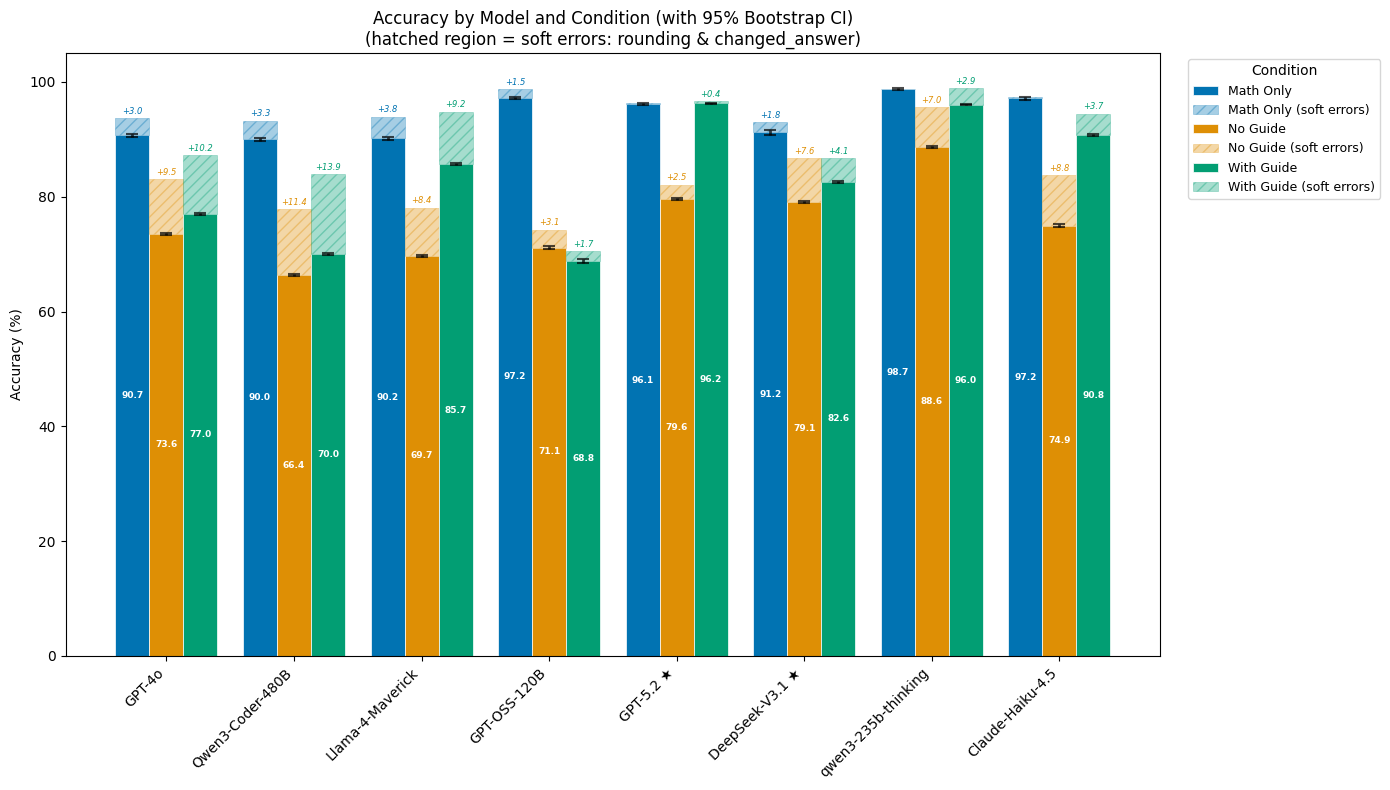

In [114]:
# bar graph — strict accuracy (solid) + soft-error band (hatched) + 95% bootstrap CI

df_all['is_correct_pct'] = df_all['is_correct'].astype(float) * 100

cond_order = ['math_only', 'in_domain_no_guide', 'in_domain_with_guide']
cond_labels = {'math_only': 'Math Only', 'in_domain_no_guide': 'No Guide', 'in_domain_with_guide': 'With Guide'}
palette = sns.color_palette('colorblind', n_colors=len(cond_order))
cond_colors = dict(zip(cond_order, palette))

models = [m for m in ALL_MODELS if m in df_all['model'].unique()]
n_models = len(models)
n_conds = len(cond_order)
bar_width = 0.8 / n_conds
x = np.arange(n_models)

agg = (
    df_all.groupby(['model', 'condition'])
    .agg(strict=('is_correct', 'mean'), soft=('is_correct_soft', 'mean'))
    .mul(100)
    .reset_index()
)

rng = np.random.default_rng(42)
N_BOOT = 10_000

def bootstrap_ci(series, n_boot=N_BOOT, ci=95):
    """Return (lower, upper) of bootstrap CI for the mean (in %)."""
    vals = series.values
    n = len(vals)
    if n == 0:
        return (0, 0)
    boot_means = np.array([vals[rng.integers(0, n, size=n)].mean() for _ in range(n_boot)]) * 100
    lo = np.percentile(boot_means, (100 - ci) / 2)
    hi = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return (lo, hi)

fig, ax = plt.subplots(figsize=(14, 8))

for j, cond in enumerate(cond_order):
    offsets = x + (j - (n_conds - 1) / 2) * bar_width
    strict_vals, soft_vals, ci_lo, ci_hi = [], [], [], []
    for m in models:
        row = agg[(agg['model'] == m) & (agg['condition'] == cond)]
        strict_vals.append(row['strict'].values[0] if len(row) else 0)
        soft_vals.append(row['soft'].values[0] if len(row) else 0)
        sub = df_all[(df_all['model'] == m) & (df_all['condition'] == cond)]['is_correct']
        lo, hi = bootstrap_ci(sub)
        ci_lo.append(lo)
        ci_hi.append(hi)

    strict_vals = np.array(strict_vals)
    soft_vals = np.array(soft_vals)
    soft_extra = soft_vals - strict_vals
    ci_lo = np.array(ci_lo)
    ci_hi = np.array(ci_hi)
    yerr_lo = strict_vals - ci_lo
    yerr_hi = ci_hi - strict_vals

    ax.bar(offsets, strict_vals, bar_width, color=cond_colors[cond],
           edgecolor='white', linewidth=0.5, label=cond_labels[cond],
           yerr=[yerr_lo, yerr_hi], error_kw=dict(elinewidth=2, capsize=4, capthick=1.5, ecolor='black', alpha=0.7))
    ax.bar(offsets, soft_extra, bar_width, bottom=strict_vals,
           color=cond_colors[cond], alpha=0.35, hatch='///',
           edgecolor=cond_colors[cond], linewidth=0.5,
           label=f'{cond_labels[cond]} (soft errors)' if j == 0 or True else '')

    for k, off in enumerate(offsets):
        if soft_extra[k] > 0.3:
            ax.text(off, soft_vals[k] + 0.4, f'+{soft_extra[k]:.1f}',
                    ha='center', va='bottom', fontsize=6, color=cond_colors[cond], fontstyle='italic')
        ax.text(off, strict_vals[k] / 2, f'{strict_vals[k]:.1f}',
                ha='center', va='center', fontsize=6.5, color='white', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([MODEL_DISPLAY.get(m, m) for m in models], rotation=45, ha='right')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy by Model and Condition (with 95% Bootstrap CI)\n(hatched region = soft errors: rounding & changed_answer)')
ax.set_ylim(0, 105)

handles, labels = ax.get_legend_handles_labels()
seen = {}
unique_handles, unique_labels = [], []
for h, l in zip(handles, labels):
    if l not in seen:
        seen[l] = True
        unique_handles.append(h)
        unique_labels.append(l)
ax.legend(unique_handles, unique_labels, title='Condition',
          bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

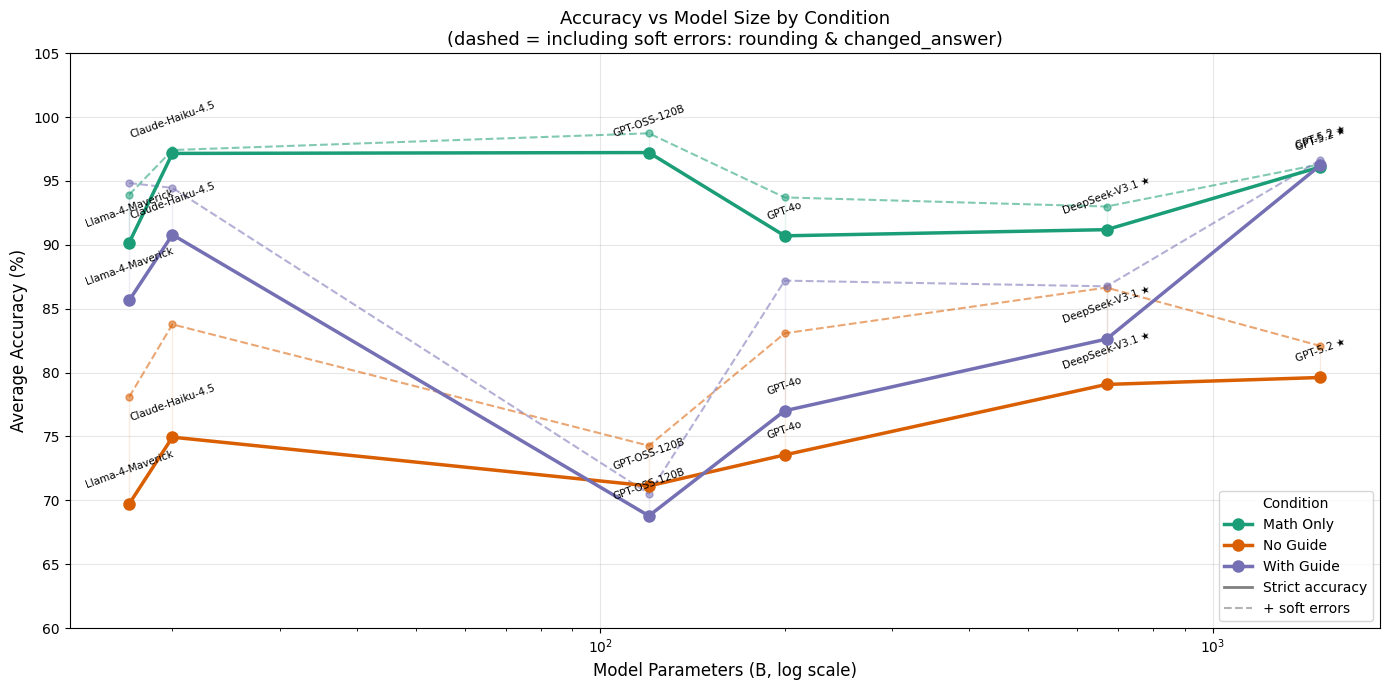

In [80]:
# Accuracy vs Model Parameter Size — strict (solid) + soft (dashed)

MODEL_PARAMS_B = {
    'llama-4':              17,
    'gpt-oss-120b':        120,
    'claude-haiku-4-5':    20,
    'gpt-4o':              200,
    'qwen3-235b-thinking': 235,
    'deepseek-v3.1':       671,
    'qwen-coder':          480,
    'gpt-5.2':             1500,
}

line_df = (
    df_all.groupby(['model', 'condition'])
    .agg(strict=('is_correct', 'mean'), soft=('is_correct_soft', 'mean'))
    .mul(100)
    .reset_index()
)
line_df = line_df[~line_df['model'].str.contains('qwen')]
line_df['params_b'] = line_df['model'].map(MODEL_PARAMS_B)

cond_order = ['math_only', 'in_domain_no_guide', 'in_domain_with_guide']
cond_labels = {'math_only': 'Math Only', 'in_domain_no_guide': 'No Guide', 'in_domain_with_guide': 'With Guide'}
cond_colors = {'math_only': '#1b9e77', 'in_domain_no_guide': '#d95f02', 'in_domain_with_guide': '#7570b3'}

fig, ax = plt.subplots(figsize=(14, 7))

for cond in cond_order:
    sub = line_df[line_df['condition'] == cond].sort_values('params_b')
    ax.plot(sub['params_b'], sub['strict'], marker='o', linewidth=2.5,
            markersize=8, label=cond_labels[cond], color=cond_colors[cond], zorder=3)
    ax.plot(sub['params_b'], sub['soft'], marker='o', linewidth=1.5,
            markersize=5, linestyle='--', color=cond_colors[cond], alpha=0.55, zorder=2)

    for _, row in sub.iterrows():
        gap = row['soft'] - row['strict']
        display = MODEL_DISPLAY.get(row['model'], row['model'])
        ax.annotate(display, (row['params_b'], row['strict']),
                    textcoords='offset points', xytext=(0, 10),
                    fontsize=7.5, ha='center', va='bottom', rotation=20)
        if gap > 0.3:
            ax.fill_between([row['params_b']], row['strict'], row['soft'],
                            color=cond_colors[cond], alpha=0.12)

ax.plot([], [], linestyle='-', color='gray', linewidth=2, label='Strict accuracy')
ax.plot([], [], linestyle='--', color='gray', linewidth=1.5, alpha=0.6, label='+ soft errors')

ax.set_xscale('log')
ax.set_xlabel('Model Parameters (B, log scale)', fontsize=12)
ax.set_ylabel('Average Accuracy (%)', fontsize=12)
ax.set_title('Accuracy vs Model Size by Condition\n(dashed = including soft errors: rounding & changed_answer)', fontsize=13)
ax.legend(title='Condition', fontsize=10)
ax.grid(alpha=0.3)
ax.set_ylim(60, 105)

plt.tight_layout()
plt.show()

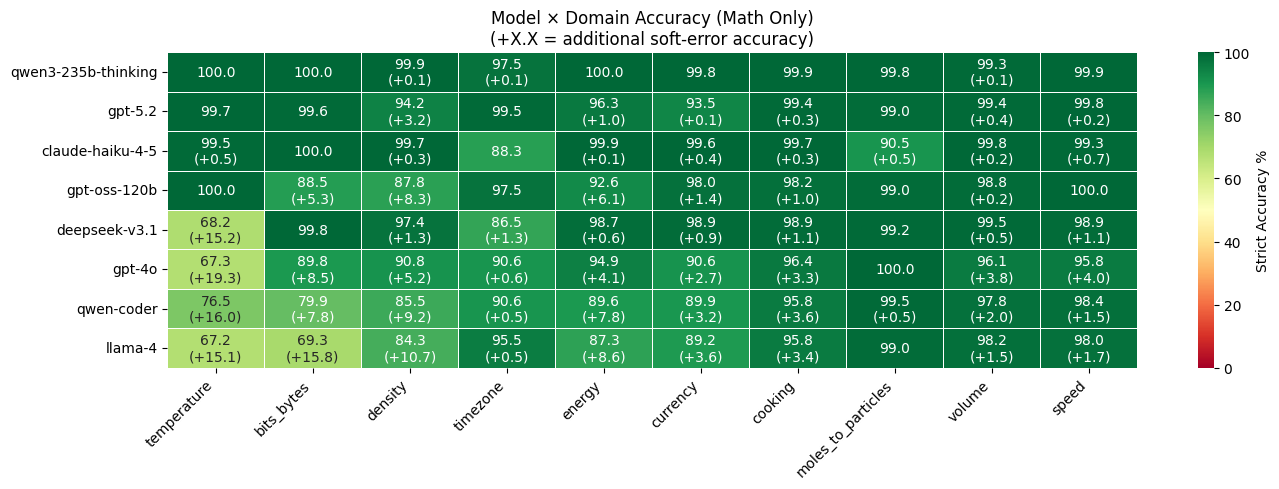

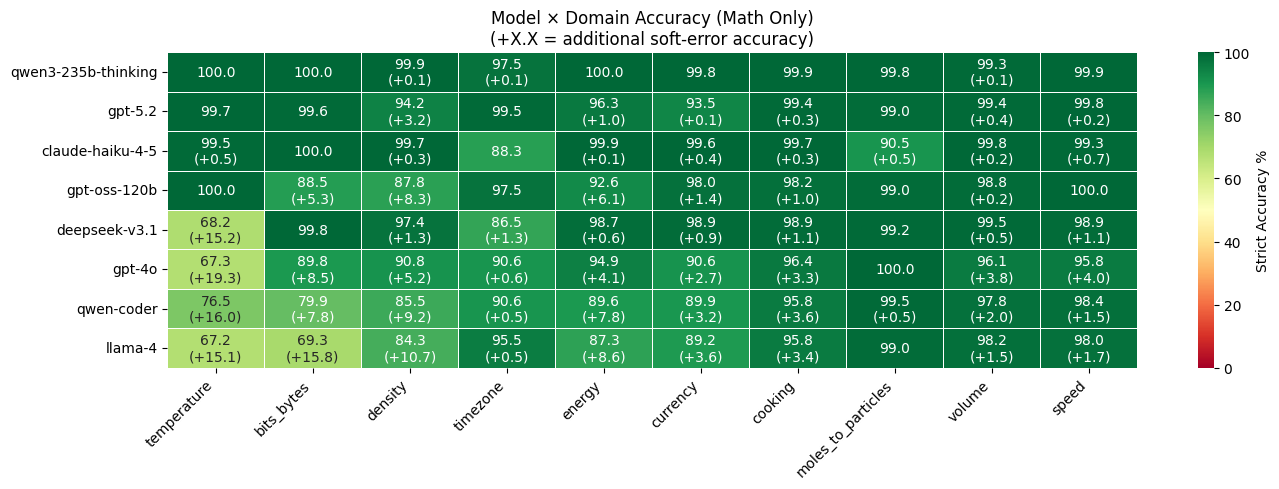

In [81]:
# heatmaps — strict accuracy colored, soft accuracy annotated below

def make_accuracy_heatmap(df_all, condition, title):
    """Heatmap with strict accuracy as color + soft accuracy annotation."""
    sub = df_all[df_all['condition'] == condition]
    strict = sub.groupby(['model', 'domain'])['is_correct'].mean().mul(100).unstack(fill_value=0)
    soft = sub.groupby(['model', 'domain'])['is_correct_soft'].mean().mul(100).unstack(fill_value=0)
    strict = strict.loc[strict.mean(axis=1).sort_values(ascending=False).index,
                        strict.mean(axis=0).sort_values(ascending=True).index]
    soft = soft.reindex(index=strict.index, columns=strict.columns, fill_value=0)

    annot_text = strict.copy().astype(str)
    for r in strict.index:
        for c in strict.columns:
            s = strict.loc[r, c]
            sf = soft.loc[r, c]
            gap = sf - s
            if gap > 0.05:
                annot_text.loc[r, c] = f'{s:.1f}\n(+{gap:.1f})'
            else:
                annot_text.loc[r, c] = f'{s:.1f}'

    fig, ax = plt.subplots(figsize=(14, 5))
    sns.heatmap(strict, annot=annot_text, fmt='', cmap='RdYlGn', vmin=0, vmax=100,
                linewidths=0.5, cbar_kws={'label': 'Strict Accuracy %'}, ax=ax)
    ax.set_title(f'{title}\n(+X.X = additional soft-error accuracy)')
    ax.set_xlabel('')
    ax.set_ylabel('')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    return fig

make_accuracy_heatmap(df_all, 'math_only', 'Model × Domain Accuracy (Math Only)')

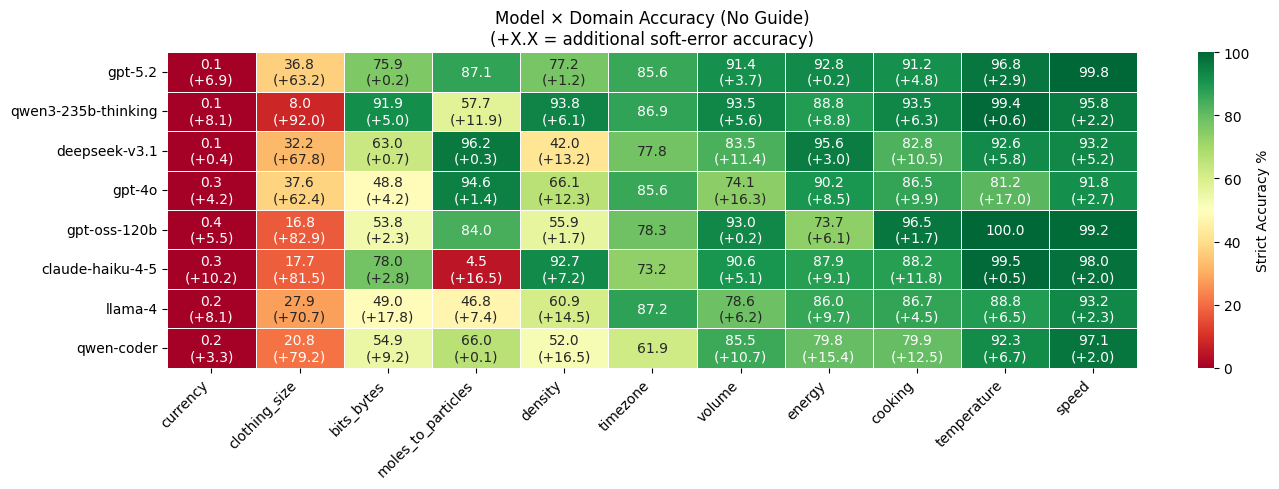

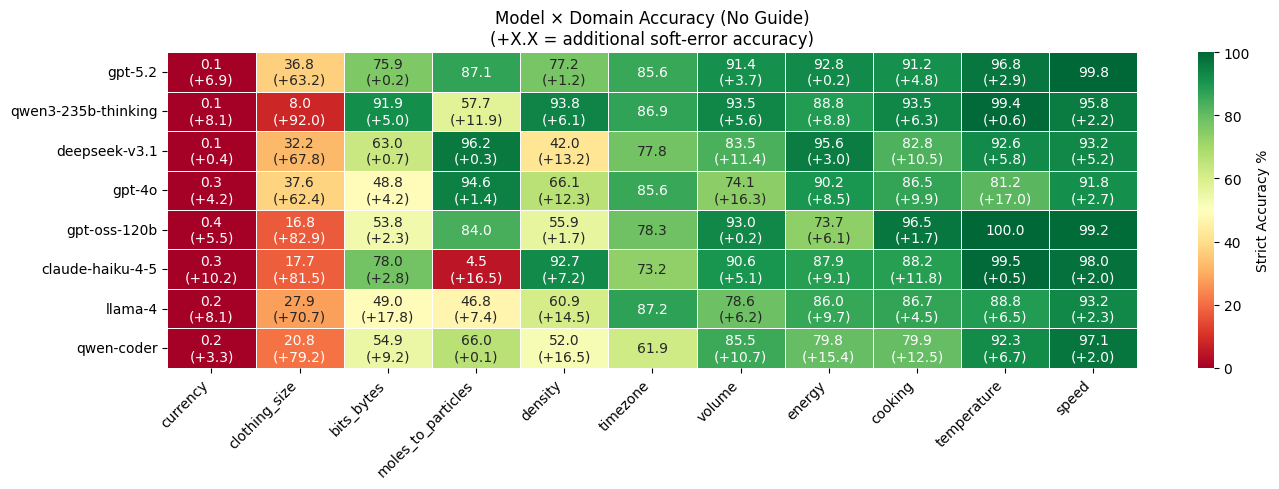

In [82]:
make_accuracy_heatmap(df_all, 'in_domain_no_guide', 'Model × Domain Accuracy (No Guide)')

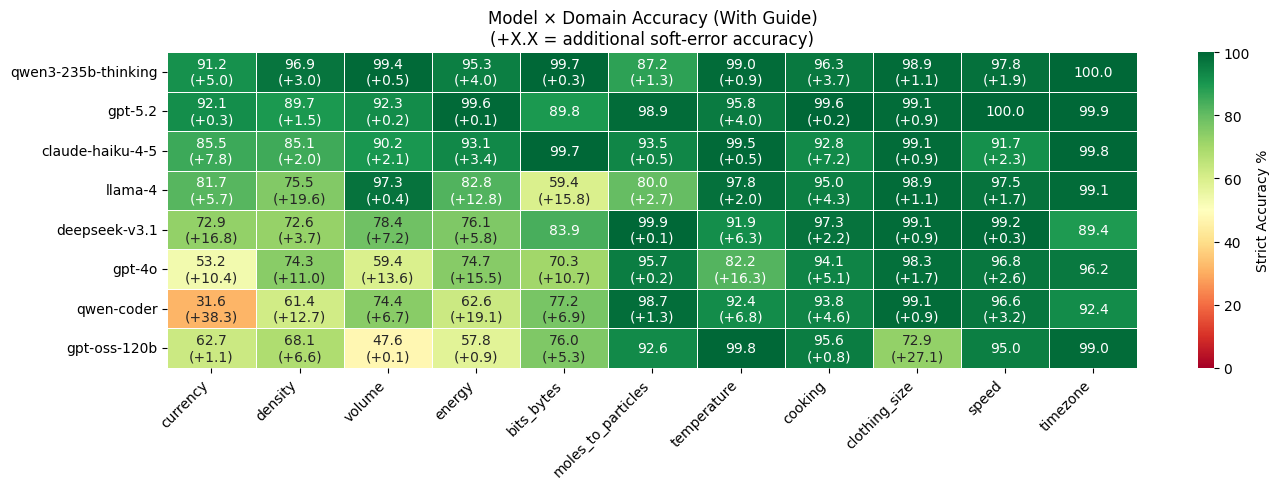

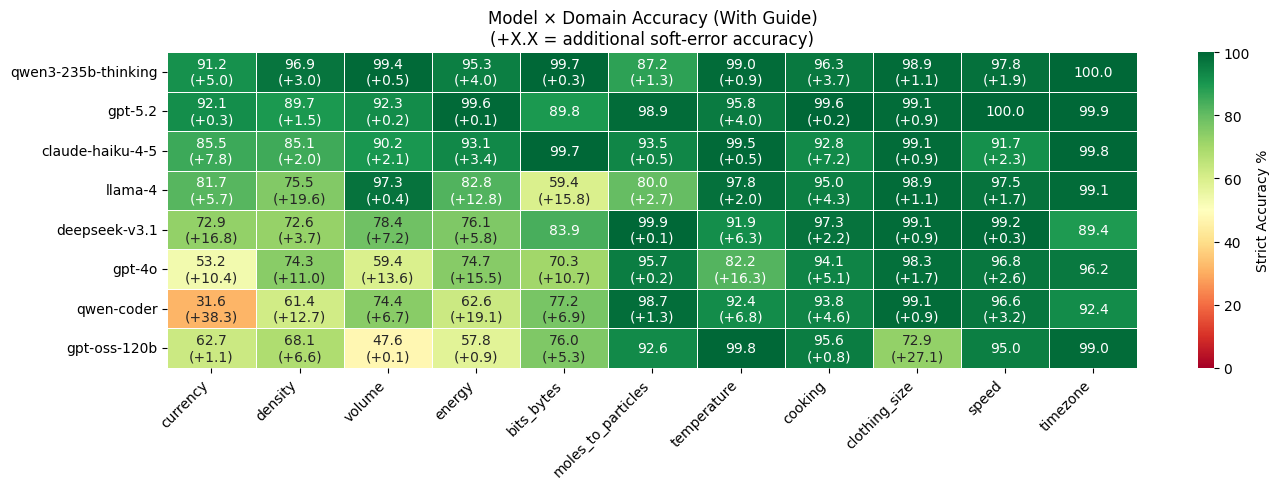

In [83]:
make_accuracy_heatmap(df_all, 'in_domain_with_guide', 'Model × Domain Accuracy (With Guide)')

relative difficulty of each domain

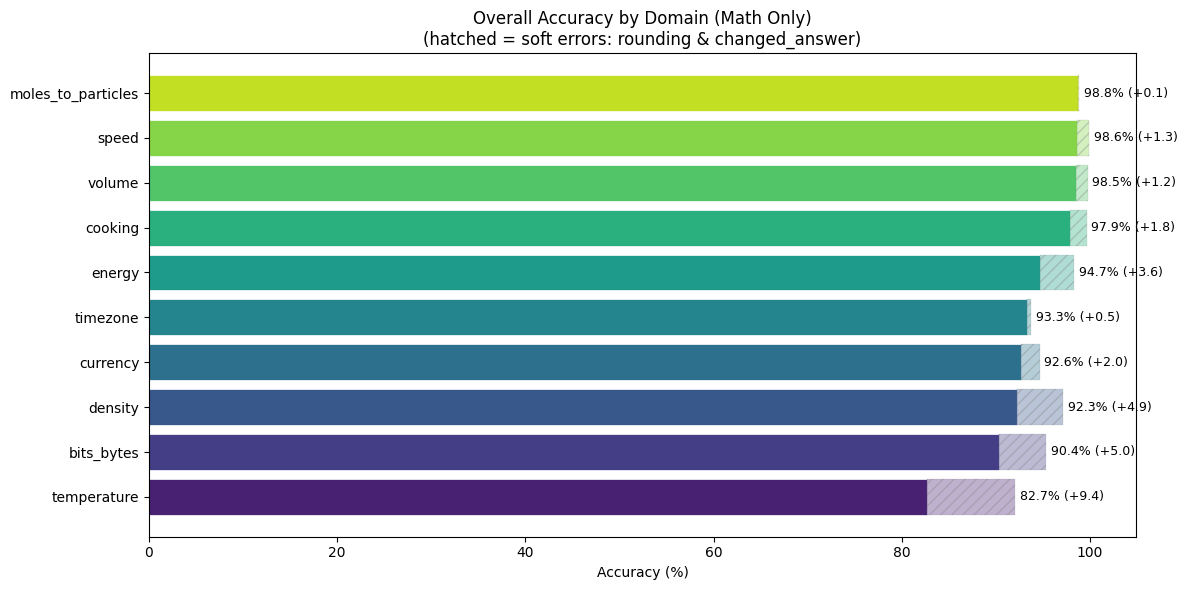

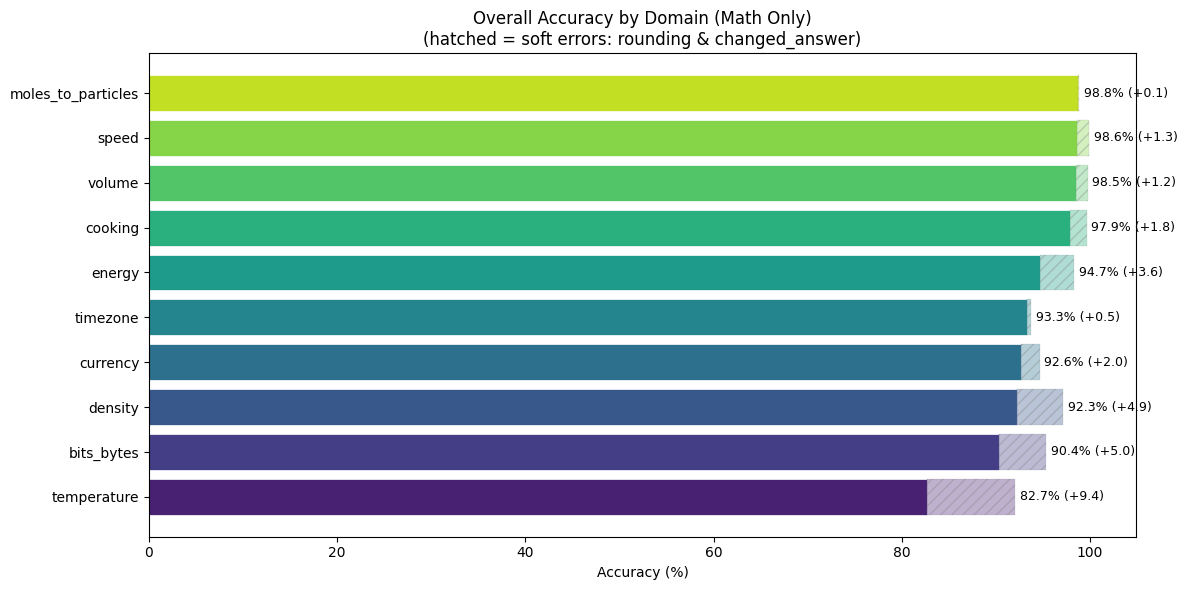

In [84]:
def domain_difficulty_chart(df_all, condition, title):
    """Horizontal bar chart: strict accuracy (solid) + soft extra (hatched)."""
    sub = df_all[df_all['condition'] == condition]
    agg = sub.groupby('domain').agg(
        strict=('is_correct', 'mean'), soft=('is_correct_soft', 'mean')
    ).mul(100).sort_values('strict', ascending=True)

    fig, ax = plt.subplots(figsize=(12, 6))
    y = np.arange(len(agg))
    ax.barh(y, agg['strict'], color=sns.color_palette('viridis', len(agg)),
            edgecolor='white', linewidth=0.5)
    soft_extra = agg['soft'] - agg['strict']
    ax.barh(y, soft_extra, left=agg['strict'],
            color=sns.color_palette('viridis', len(agg)), alpha=0.35,
            hatch='///', edgecolor='gray', linewidth=0.3)

    ax.set_yticks(y)
    ax.set_yticklabels(agg.index)
    ax.set_xlabel('Accuracy (%)')
    ax.set_title(f'{title}\n(hatched = soft errors: rounding & changed_answer)')

    for i, (s, se) in enumerate(zip(agg['strict'], soft_extra)):
        ax.text(s + se + 0.5, i, f'{s:.1f}% (+{se:.1f})', va='center', fontsize=9)

    plt.tight_layout()
    return fig

domain_difficulty_chart(df_all, 'math_only', 'Overall Accuracy by Domain (Math Only)')

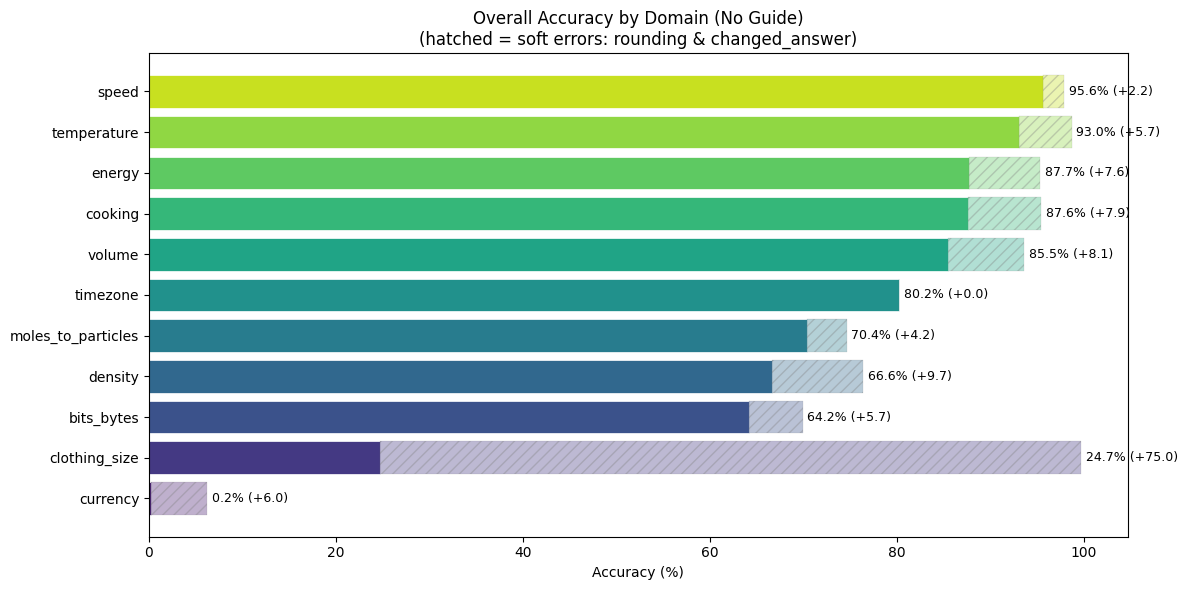

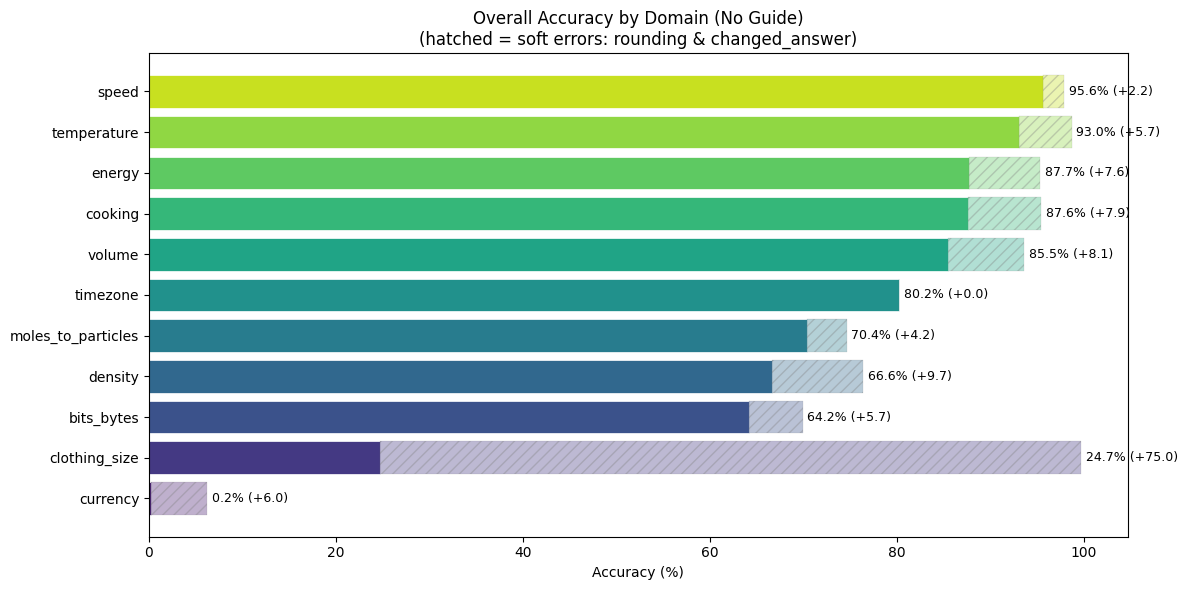

In [85]:
domain_difficulty_chart(df_all, 'in_domain_no_guide', 'Overall Accuracy by Domain (No Guide)')

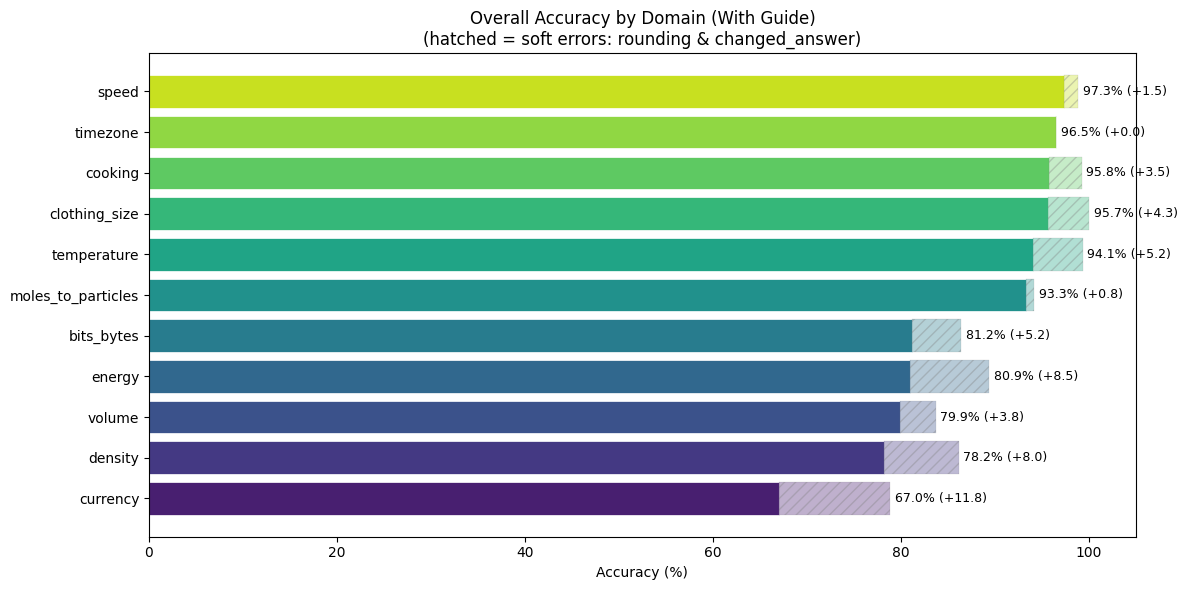

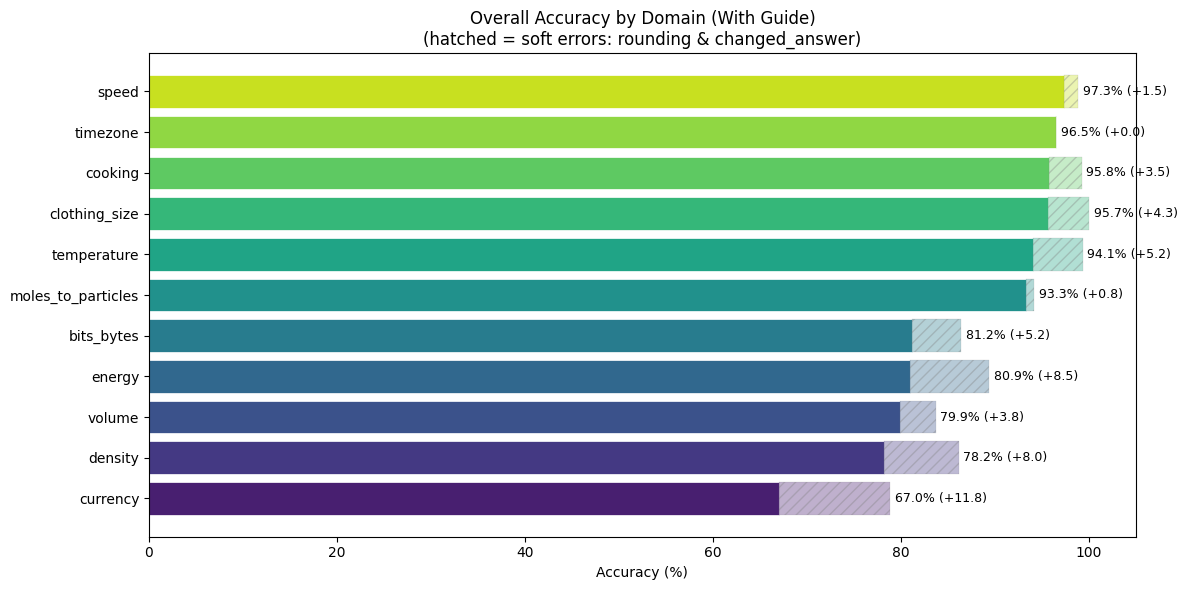

In [86]:
domain_difficulty_chart(df_all, 'in_domain_with_guide', 'Overall Accuracy by Domain (With Guide)')

In [87]:
df_freq_acc = df_all.groupby(['frequency'])['is_correct'].agg(['mean', 'count']).rename(columns={'mean': 'accuracy', 'count': 'n'}).reset_index()

In [88]:
df_freq_acc['accuracy_%'] = df_freq_acc['accuracy'].mul(100)

In [89]:
df_freq_acc['domain_difficulty'] = df_freq_acc['accuracy_%'].apply(lambda x: 'easy' if x > 50 else 'hard')
df_freq_acc.sample(20)

,frequency,accuracy,n,accuracy_%,domain_difficulty
86,100410.0,0.586724,11946,58.672359,easy
26,70.0,0.772225,11946,77.222501,easy
173,13695120.0,0.800533,17622,80.053342,easy
150,5358253.0,0.814834,17622,81.483373,easy
155,7513711.0,0.815061,17622,81.506072,easy
137,2500553.0,0.830155,17622,83.015549,easy
124,1718423.0,0.800817,17622,80.081716,easy
111,1012759.0,0.814266,17622,81.426626,easy
107,754922.0,0.632812,128,63.281250,easy
209,76986440.0,0.775606,17750,77.560563,easy


In [90]:
df_freq_acc_with_models = df_all.groupby(['frequency', 'model', 'is_reasoning'])['is_correct'].agg(['mean', 'count']).rename(columns={'mean': 'accuracy', 'count': 'n'}).reset_index()

In [91]:
df_freq_acc_with_models['accuracy_%'] = df_freq_acc_with_models['accuracy'].mul(100)
df_freq_acc_with_models.sample(20)

,frequency,model,is_reasoning,accuracy,n,accuracy_%
414,1582.0,qwen-coder,False,0.518625,2094,51.862464
816,1646325.0,gpt-oss-120b,False,0.729825,2280,72.982456
658,511854.0,qwen-coder,False,0.733772,2280,73.377193
890,2178965.0,qwen-coder,False,0.625000,8,62.500000
319,506.0,qwen3-235b-thinking,True,0.971989,1785,97.198880
354,901.0,qwen-coder,False,0.616046,2094,61.604585
1419,39925855.0,qwen3-235b-thinking,True,0.895992,1971,89.599188
1599,858798582.0,gpt-5.2,True,0.911842,2280,91.184211
958,2815738.0,gpt-4o,False,0.748684,2280,74.868421
326,654.0,deepseek-v3.1,True,0.830252,1785,83.025210


In [92]:
df_freq_acc_with_models['domain_difficulty'] = df_freq_acc_with_models['accuracy_%'].apply(lambda x: 'easy' if x > 50 else 'hard')
df_freq_acc_with_models.sample(20)

,frequency,model,is_reasoning,accuracy,n,accuracy_%,domain_difficulty
1509,89560510.0,deepseek-v3.1,True,0.870417,1991,87.041688,easy
1151,10590900.0,gpt-5.2,True,0.889474,2280,88.947368,easy
591,256800.0,gpt-5.2,True,0.840789,2280,84.078947,easy
709,984752.0,deepseek-v3.1,True,0.810249,1971,81.024860,easy
716,1012759.0,claude-haiku-4-5,True,0.867982,2280,86.798246,easy
639,340232.0,gpt-5.2,True,0.500000,2,50.000000,hard
451,5060.0,qwen3-235b-thinking,True,0.966947,1785,96.694678,easy
1496,71043598.0,gpt-oss-120b,False,0.684211,2280,68.421053,easy
1147,10480473.0,qwen3-235b-thinking,True,0.500000,4,50.000000,hard
281,262.0,llama-4,False,0.730659,2094,73.065903,easy


skipping frequency in the pile for now because statistical markers weren't compelling

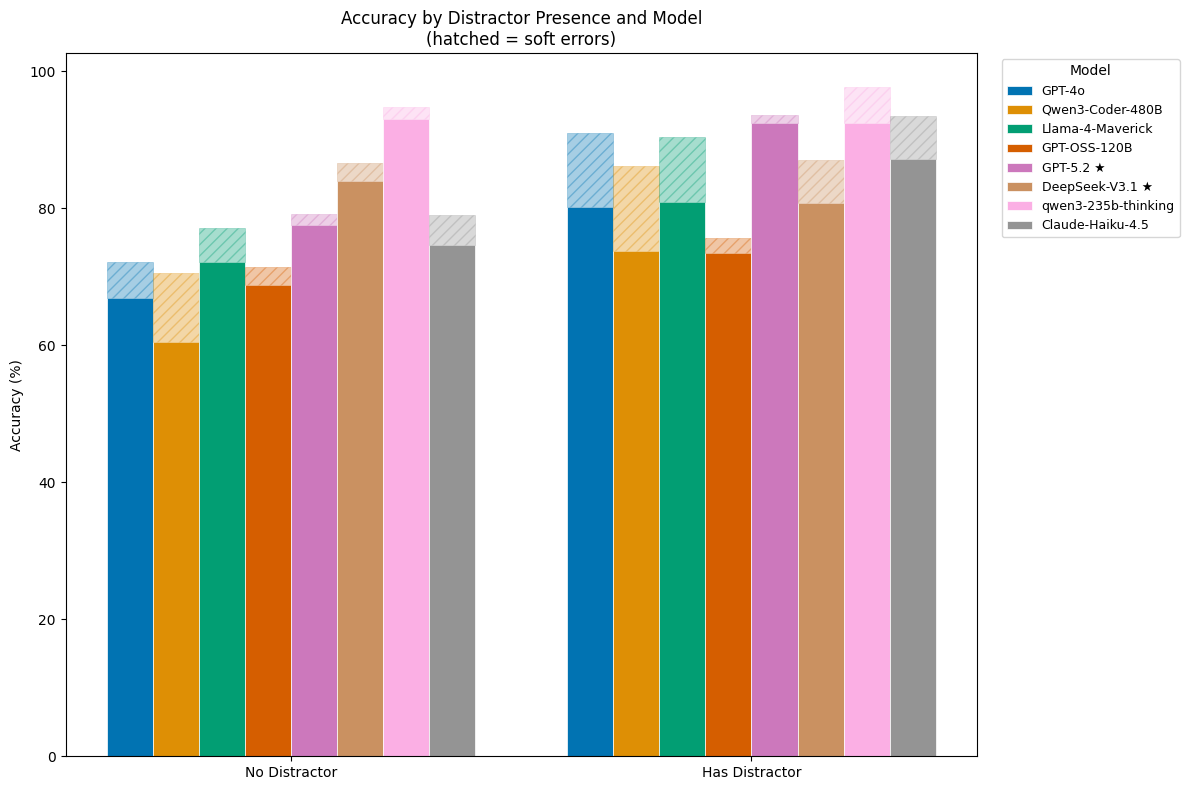

In [93]:
# distractor chart — strict + soft error band
df_all['has_distractor'] = df_all['distractor'].notna() & (df_all['distractor'] != 'null')

dist_agg = (
    df_all.groupby(['model', 'has_distractor'])
    .agg(strict=('is_correct', 'mean'), soft=('is_correct_soft', 'mean'))
    .mul(100).reset_index()
)

dist_labels = {False: 'No Distractor', True: 'Has Distractor'}
models = [m for m in ALL_MODELS if m in dist_agg['model'].unique()]
n_models = len(models)
dist_vals = [False, True]
bar_width = 0.8 / n_models
palette = sns.color_palette('colorblind', n_models)

fig, ax = plt.subplots(figsize=(12, 8))
x = np.arange(len(dist_vals))

for j, m in enumerate(models):
    offsets = x + (j - (n_models - 1) / 2) * bar_width
    strict_vals, soft_vals = [], []
    for d in dist_vals:
        row = dist_agg[(dist_agg['model'] == m) & (dist_agg['has_distractor'] == d)]
        strict_vals.append(row['strict'].values[0] if len(row) else 0)
        soft_vals.append(row['soft'].values[0] if len(row) else 0)
    strict_vals = np.array(strict_vals)
    soft_extra = np.array(soft_vals) - strict_vals

    ax.bar(offsets, strict_vals, bar_width, color=palette[j],
           edgecolor='white', linewidth=0.5, label=MODEL_DISPLAY.get(m, m))
    ax.bar(offsets, soft_extra, bar_width, bottom=strict_vals,
           color=palette[j], alpha=0.35, hatch='///',
           edgecolor=palette[j], linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels([dist_labels[d] for d in dist_vals])
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy by Distractor Presence and Model\n(hatched = soft errors)')
ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

In [94]:
# distractor vs reasoning length — see cell after reasoning token extraction


In [95]:
# investigating timezone
df_timezone = df_all[(df_all['domain']=='timezone') & (df_all['condition']=='in_domain_no_guide')].copy()

# also keep aggregated stats for reference
df_timezone_stats = df_timezone.groupby(['frequency_level', 'condition', 'model']).agg({'is_correct': 'mean'}).reset_index()
df_timezone_stats['accuracy_%'] = df_timezone_stats['is_correct'].mul(100)


In [96]:
df_timezone_stats

,frequency_level,condition,model,is_correct,accuracy_%
0,rare,in_domain_no_guide,claude-haiku-4-5,0.732176,73.217593
1,rare,in_domain_no_guide,deepseek-v3.1,0.777963,77.796296
2,rare,in_domain_no_guide,gpt-4o,0.856296,85.629630
3,rare,in_domain_no_guide,gpt-5.2,0.856019,85.601852
4,rare,in_domain_no_guide,gpt-oss-120b,0.783102,78.310185
5,rare,in_domain_no_guide,llama-4,0.872315,87.231481
6,rare,in_domain_no_guide,qwen-coder,0.618611,61.861111
7,rare,in_domain_no_guide,qwen3-235b-thinking,0.868704,86.870370
8,uncommon,in_domain_no_guide,claude-haiku-4-5,NaN,NaN
9,uncommon,in_domain_no_guide,deepseek-v3.1,NaN,NaN


In [97]:
# reasoning token length

import re

def extract_reasoning_text(raw):
    """Extract reasoning trace from raw_response, checking multiple formats.
    
    Priority:
      1. [REASONING]...[/REASONING] — api.py wraps reasoning_content from the API
      2. <think>...</think>          — inline thinking tags (some Qwen responses)
      3. everything before the last <answer> tag — fallback for models like DeepSeek
         that dump chain-of-thought directly into the content with no wrapper
    """
    if pd.isna(raw):
        return ''
    raw = str(raw)
    # 1. [REASONING]...[/REASONING]
    m = re.search(r'\[REASONING\]\s*(.*?)\s*\[/REASONING\]', raw, re.DOTALL)
    if m:
        return m.group(1).strip()
    # 2. <think>...</think>
    m = re.search(r'<think>(.*?)</think>', raw, re.DOTALL)
    if m:
        return m.group(1).strip()
    # 3. fallback: everything before the last <answer> tag is reasoning
    ans_matches = list(re.finditer(r'<answer>', raw, re.IGNORECASE))
    if ans_matches:
        reasoning_part = raw[:ans_matches[-1].start()].strip()
        # only count it if there's substantial text (>50 chars) to avoid
        # false positives from short preambles like "The answer is"
        if len(reasoning_part) > 50:
            return reasoning_part
    return ''

# only apply to reasoning models
df_reason = df_all[df_all['model'].isin(REASONING_MODELS)].copy()

# extract reasoning text and approximate token count (~0.75 words per token)
df_reason['reasoning_text'] = df_reason['raw_response'].apply(extract_reasoning_text)
df_reason['reasoning_word_count'] = df_reason['reasoning_text'].str.split().str.len().fillna(0).astype(int)
df_reason['reasoning_tokens_approx'] = (df_reason['reasoning_word_count'] / 0.75).round(0).astype(int)

# use API-provided reasoning_tokens where available, otherwise use approximation
df_reason['reasoning_tokens_final'] = df_reason['reasoning_tokens'].fillna(df_reason['reasoning_tokens_approx'])
# if API value is 0 but we have text, prefer approximation
mask_zero_api = (df_reason['reasoning_tokens_final'] == 0) & (df_reason['reasoning_tokens_approx'] > 0)
df_reason.loc[mask_zero_api, 'reasoning_tokens_final'] = df_reason.loc[mask_zero_api, 'reasoning_tokens_approx']

# filter to rows that actually have reasoning
df_reasoning = df_reason[df_reason['reasoning_tokens_final'] > 0].copy()

print(f"{len(df_reasoning):,} rows with reasoning traces (out of {len(df_reason):,} reasoning-model rows)")
print(f"Models: {df_reasoning['model'].unique().tolist()}")
print(f"\nSource breakdown:")
has_api = df_reasoning['reasoning_tokens'].notna() & (df_reasoning['reasoning_tokens'] > 0)
print(f"  API-provided reasoning_tokens: {has_api.sum():,}")
print(f"  Approximated from text:        {(~has_api).sum():,}")
print(f"\nSummary stats (reasoning_tokens_final):")
df_reasoning.groupby('model')['reasoning_tokens_final'].describe().round(0)

813,593 rows with reasoning traces (out of 1,529,568 reasoning-model rows)
Models: ['claude-haiku-4-5', 'deepseek-v3.1', 'gpt-5.2', 'qwen3-235b-thinking']

Source breakdown:
  API-provided reasoning_tokens: 416,265
  Approximated from text:        397,328

Summary stats (reasoning_tokens_final):


,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
claude-haiku-4-5,241662.0,357.0,279.0,7.0,143.0,310.0,460.0,6026.0
deepseek-v3.1,13721.0,206.0,642.0,1.0,47.0,75.0,120.0,11967.0
gpt-5.2,174603.0,400.0,473.0,2.0,86.0,223.0,548.0,16000.0
qwen3-235b-thinking,383607.0,1677.0,1581.0,47.0,477.0,1079.0,2396.0,14768.0


                                    median    mean   count
model               has_distractor                        
claude-haiku-4-5    False            303.0   332.0   61662
                    True             313.0   366.0  180000
deepseek-v3.1       False             76.0   134.0   11717
                    True              59.0   627.0    2004
gpt-5.2             False            188.0   300.0   97969
                    True             301.0   529.0   76634
qwen3-235b-thinking False            793.0  1181.0   65894
                    True            1201.0  1781.0  317713


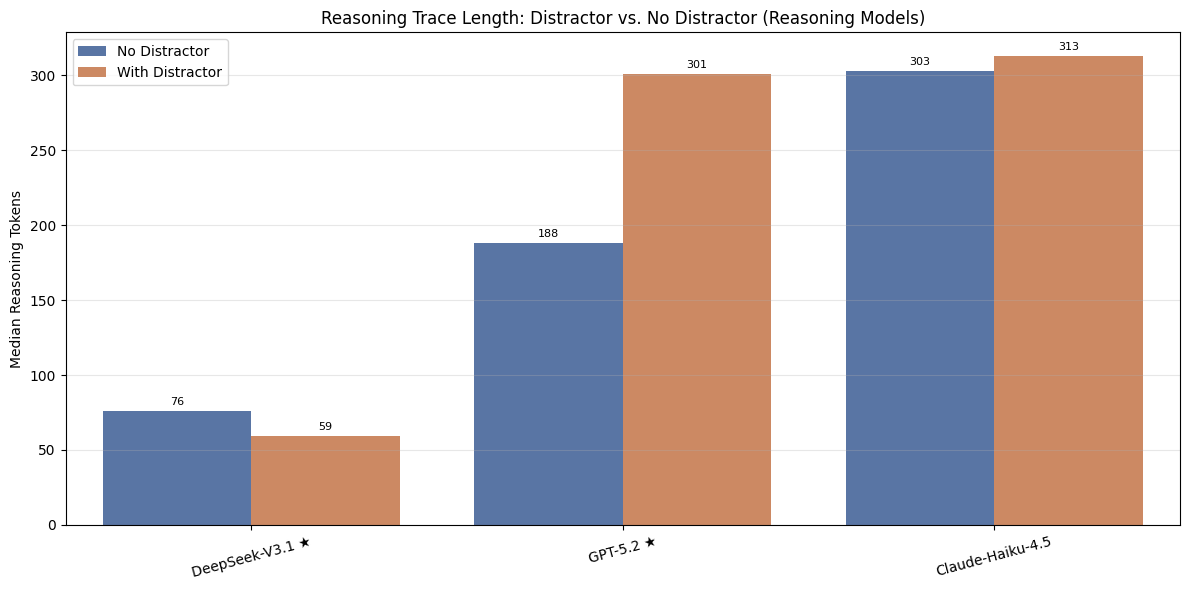

In [98]:
# Reasoning trace length: distractor vs. no distractor

df_reasoning['has_distractor'] = df_reasoning['distractor'].notna() & (df_reasoning['distractor'] != 'null')

summary = df_reasoning.groupby(['model', 'has_distractor'])['reasoning_tokens_final'].agg(['median', 'mean', 'count']).round(0)
print(summary.to_string())

plot_df = (
    df_reasoning.groupby(['model', 'has_distractor'])['reasoning_tokens_final']
    .median()
    .reset_index()
    .rename(columns={'reasoning_tokens_final': 'median_tokens'})
)
plot_df['display_name'] = plot_df['model'].map(MODEL_DISPLAY)
plot_df['distractor_label'] = plot_df['has_distractor'].map({True: 'With Distractor', False: 'No Distractor'})

fig, ax = plt.subplots(figsize=(12, 6))
models_sorted = plot_df.groupby('display_name')['median_tokens'].mean().sort_values().index.tolist()
sns.barplot(
    data=plot_df, x='display_name', y='median_tokens', hue='distractor_label',
    order=models_sorted, palette=['#4c72b0', '#dd8452'],
    ax=ax
)
ax.set_xlabel('')
ax.set_ylabel('Median Reasoning Tokens')
ax.set_title('Reasoning Trace Length: Distractor vs. No Distractor (Reasoning Models)')
ax.legend(title='')
ax.grid(axis='y', alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=8, padding=3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [99]:
# reasoning by domain
df_reasoning.groupby(['domain', 'model'])['reasoning_tokens_final'].describe().round(0)
# reasoning by domain & condition
df_reasoning.groupby(['domain', 'condition', 'model'])['reasoning_tokens_final'].describe().round(0)


count    mean     std  \
domain     condition            model                                          
bits_bytes in_domain_no_guide   claude-haiku-4-5       600.0   187.0   131.0   
                                qwen3-235b-thinking   1200.0  1005.0  1212.0   
           in_domain_with_guide claude-haiku-4-5       600.0   480.0   344.0   
                                deepseek-v3.1            1.0    41.0     NaN   
                                qwen3-235b-thinking   1200.0  1400.0  1046.0   
...                                                      ...     ...     ...   
volume     in_domain_with_guide gpt-5.2              17193.0   591.0   640.0   
                                qwen3-235b-thinking  18600.0  1832.0  1751.0   
           math_only            claude-haiku-4-5       600.0   226.0   193.0   
                                deepseek-v3.1           22.0    57.0    97.0   
                                qwen3-235b-thinking   1200.0  1018.0   964.0   

                                                       min    25%     50%  \
domain     condition            model                                       
bits_bytes in_domain_no_guide   claude-haiku-4-5      32.0   62.0   169.0   
                                qwen3-235b-thinking  139.0  280.0   500.0   
           in_domain_with_guide claude-haiku-4-5      73.0  181.0   412.0   
                                deepseek-v3.1         41.0   41.0    41.0   
                                qwen3-235b-thinking  145.0  581.0  1150.0   
...                                                    ...    ...     ...   
volume     in_domain_with_guide gpt-5.2                8.0   49.0   487.0   
                                qwen3-235b-thinking   79.0  428.0  1223.0   
           math_only            claude-haiku-4-5       9.0   74.0   181.0   
                                deepseek-v3.1          8.0   12.0    14.0   
                                qwen3-235b-thinking  104.0  348.0   612.0   

                                                        75%     max  
domain     condition            model                                
bits_bytes in_domain_no_guide   claude-haiku-4-5      262.0   769.0  
                                qwen3-235b-thinking  1140.0  7375.0  
           in_domain_with_guide claude-haiku-4-5      718.0  1806.0  
                                deepseek-v3.1          41.0    41.0  
                                qwen3-235b-thinking  1861.0  6348.0  
...                                                     ...     ...  
volume     in_domain_with_guide gpt-5.2               862.0  6753.0  
                                qwen3-235b-thinking  2625.0  9471.0  
           math_only            claude-haiku-4-5      323.0  1345.0  
                                deepseek-v3.1          79.0   461.0  
                                qwen3-235b-thinking  1363.0  5656.0  

[99 rows x 8 columns]

In [100]:
df_reasoning_ng = df_reasoning[df_reasoning['condition'] == 'in_domain_no_guide'].copy()

In [101]:
df_reasoning_ng['model'].unique()

array(['claude-haiku-4-5', 'deepseek-v3.1', 'gpt-5.2',
       'qwen3-235b-thinking'], dtype=object)

In [102]:
df_stats['model'].unique()

array(['claude-haiku-4-5', 'deepseek-v3.1', 'gpt-4o', 'gpt-5.2',
       'gpt-oss-120b', 'llama-4', 'qwen-coder', 'qwen3-235b-thinking'],
      dtype=object)

=== Reasoning Token Length: Correct vs Wrong ===
  Correct  — n=721,043  mean=989  median=459
  Wrong    — n=92,550  mean=964  median=460
  Mann-Whitney U p-value: 3.03e-240

=== Per-Model: Median Reasoning Tokens (Correct vs Wrong) ===
  claude-haiku-4-5          correct median=   276  wrong median=   426  p=0.00e+00
  deepseek-v3.1             correct median=    71  wrong median=    99  p=1.56e-53
  gpt-5.2                   correct median=   187  wrong median=   349  p=0.00e+00
  qwen3-235b-thinking       correct median=  1049  wrong median=  1469  p=0.00e+00


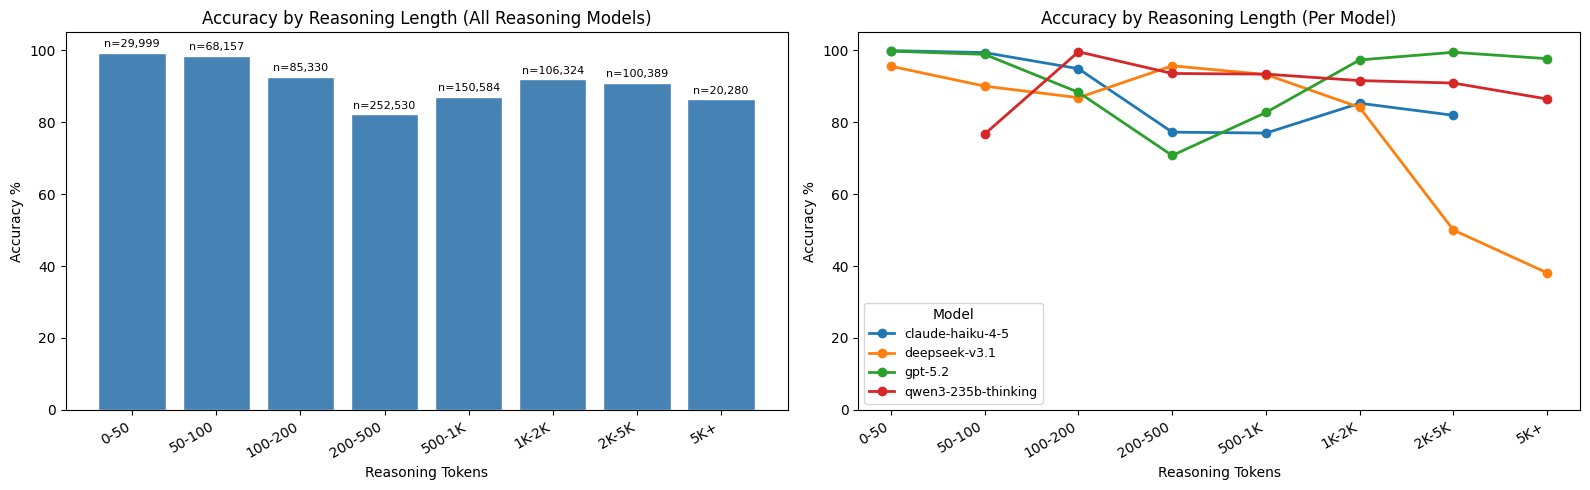


=== Point-Biserial Correlation: reasoning_tokens vs is_correct ===
Model                    Domain                     r          p       n
------------------------------------------------------------------------
  claude-haiku-4-5         currency              -0.219   0.00e+00  33,600
  claude-haiku-4-5         cooking               -0.323   0.00e+00  37,800
  claude-haiku-4-5         moles_to_particles    -0.369   0.00e+00  12,600
  claude-haiku-4-5         volume                -0.320   0.00e+00  37,800
  gpt-5.2                  timezone              -0.375   0.00e+00  32,395
  qwen3-235b-thinking      timezone              -0.233   0.00e+00  32,400
  claude-haiku-4-5         energy                -0.114  1.18e-181  63,000
  qwen3-235b-thinking      energy                -0.073  7.97e-146 123,877
  claude-haiku-4-5         clothing_size         -0.624   4.60e-77     702
  qwen3-235b-thinking      volume                -0.064   2.63e-53  57,000
  deepseek-v3.1            volume   

In [103]:
# ── Reasoning trace length vs correctness (row-level) ──
# Does spending more tokens reasoning actually help the model get the right answer?

from scipy import stats as sp_stats

df_rt = df_reasoning.copy()
df_rt['is_correct'] = df_rt['loss'] == 0.0

# --- 1. Overall: correct vs incorrect reasoning length ---
correct_tokens = df_rt[df_rt['is_correct']]['reasoning_tokens_final']
wrong_tokens = df_rt[~df_rt['is_correct']]['reasoning_tokens_final']

print("=== Reasoning Token Length: Correct vs Wrong ===")
print(f"  Correct  — n={len(correct_tokens):,}  mean={correct_tokens.mean():.0f}  median={correct_tokens.median():.0f}")
print(f"  Wrong    — n={len(wrong_tokens):,}  mean={wrong_tokens.mean():.0f}  median={wrong_tokens.median():.0f}")
u_stat, p_val = sp_stats.mannwhitneyu(correct_tokens, wrong_tokens, alternative='two-sided')
print(f"  Mann-Whitney U p-value: {p_val:.2e}")

# --- 2. Per-model breakdown ---
print("\n=== Per-Model: Median Reasoning Tokens (Correct vs Wrong) ===")
for model in sorted(df_rt['model'].unique()):
    sub = df_rt[df_rt['model'] == model]
    c = sub[sub['is_correct']]['reasoning_tokens_final']
    w = sub[~sub['is_correct']]['reasoning_tokens_final']
    if len(c) > 0 and len(w) > 0:
        _, p = sp_stats.mannwhitneyu(c, w, alternative='two-sided')
        print(f"  {model:<24s}  correct median={c.median():>6.0f}  wrong median={w.median():>6.0f}  p={p:.2e}")

# --- 3. Binned analysis: bucket reasoning tokens and plot accuracy ---
df_rt['token_bin'] = pd.cut(
    df_rt['reasoning_tokens_final'],
    bins=[0, 50, 100, 200, 500, 1000, 2000, 5000, np.inf],
    labels=['0-50', '50-100', '100-200', '200-500', '500-1K', '1K-2K', '2K-5K', '5K+']
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 3a. All reasoning models combined
binned = df_rt.groupby('token_bin', observed=True).agg(
    accuracy=('is_correct', 'mean'),
    n=('is_correct', 'size')
).reset_index()
binned['accuracy_pct'] = binned['accuracy'] * 100

ax = axes[0]
bars = ax.bar(binned['token_bin'].astype(str), binned['accuracy_pct'], color='steelblue', edgecolor='white')
for bar, row in zip(bars, binned.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'n={row.n:,}', ha='center', va='bottom', fontsize=8)
ax.set_xlabel('Reasoning Tokens')
ax.set_ylabel('Accuracy %')
ax.set_title('Accuracy by Reasoning Length (All Reasoning Models)')
ax.set_ylim(0, 105)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# 3b. Per-model lines
ax = axes[1]
for model in sorted(df_rt['model'].unique()):
    sub = df_rt[df_rt['model'] == model]
    mb = sub.groupby('token_bin', observed=True)['is_correct'].agg(['mean', 'size']).reset_index()
    mb = mb[mb['size'] >= 20]  # skip bins with too few samples
    ax.plot(mb['token_bin'].astype(str), mb['mean'] * 100, marker='o', label=model, linewidth=2)

ax.set_xlabel('Reasoning Tokens')
ax.set_ylabel('Accuracy %')
ax.set_title('Accuracy by Reasoning Length (Per Model)')
ax.legend(title='Model', fontsize=9)
ax.set_ylim(0, 105)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

# --- 4. Per-model × domain: point-biserial correlation ---
print("\n=== Point-Biserial Correlation: reasoning_tokens vs is_correct ===")
print(f"{'Model':<24s} {'Domain':<20s} {'r':>7s} {'p':>10s} {'n':>7s}")
print("-" * 72)
corr_rows = []
for (model, domain), g in df_rt.groupby(['model', 'domain']):
    if len(g) < 30 or g['is_correct'].nunique() < 2:
        continue
    r, p = sp_stats.pointbiserialr(g['is_correct'].astype(int), g['reasoning_tokens_final'])
    corr_rows.append({'model': model, 'domain': domain, 'r': r, 'p': p, 'n': len(g)})
corr_df = pd.DataFrame(corr_rows).sort_values('p')
for _, row in corr_df.head(20).iterrows():
    p_str = f"{row['p']:.2e}" if row['p'] < 0.001 else f"{row['p']:.4f}"
    print(f"  {row['model']:<24s} {row['domain']:<20s} {row['r']:>7.3f} {p_str:>10s} {row['n']:>7,d}")

print(f"\nSignificant (p<0.01): {(corr_df['p'] < 0.01).sum()} / {len(corr_df)} model×domain combos")
print(f"Positive r (longer = more correct): {(corr_df['r'] > 0).sum()} / {len(corr_df)}")
print(f"Negative r (longer = less correct): {(corr_df['r'] < 0).sum()} / {len(corr_df)}")

In [104]:
# # ── scatter: mean reasoning tokens (x) vs accuracy (y) per model × domain ──
# # each dot = one model+condition+domain combo (reasoning models only)

# # aggregate mean reasoning tokens at the same level as df_stats_ci
# reasoning_agg = (
#     df_reasoning_ng
#     .groupby(['model', 'condition', 'domain'])['reasoning_tokens_final']
#     .mean()
#     .reset_index()
#     .rename(columns={'reasoning_tokens_final': 'mean_reasoning_tokens'})
# )

# # start from stats for in_domain_no_guide so all reasoning models appear (even without token data)
# stats_ng = df_stats[
#     (df_stats['model'].isin(REASONING_MODELS)) & (df_stats['condition'] == 'in_domain_no_guide')
# ]
# scatter_df = stats_ng.merge(
#     reasoning_agg, on=['model', 'condition', 'domain'], how='left'
# )
# # show models missing from reasoning_agg (e.g. gpt-5.2 if API didn't return reasoning_tokens)
# missing = scatter_df['mean_reasoning_tokens'].isna()
# if missing.any():
#     models_missing = scatter_df.loc[missing, 'model'].unique().tolist()
#     print(f"Models with no reasoning token data (will plot at 1 token): {models_missing}")
# scatter_df['mean_reasoning_tokens'] = scatter_df['mean_reasoning_tokens'].fillna(1.0)  # 1 so visible on log scale
# print(f"{len(scatter_df)} points (model × condition × domain, reasoning models only)")

# fig, ax = plt.subplots(figsize=(14, 8))
# palette = sns.color_palette('colorblind', n_colors=scatter_df['model'].nunique())
# model_colors = dict(zip(scatter_df['model'].unique(), palette))

# sns.scatterplot(
#     data=scatter_df, x='mean_reasoning_tokens', y='accuracy_%',
#     hue='model', style='condition', s=80, alpha=0.7,
#     palette=model_colors, ax=ax,
# )

# from scipy import stats

# # per-model regression lines + stats
# reasoning_reg_results = []
# for model, color in model_colors.items():
#     model_data = scatter_df[scatter_df['model'] == model].copy()
#     model_data = model_data[model_data['mean_reasoning_tokens'] > 0]
#     if len(model_data) > 2 and model_data['mean_reasoning_tokens'].nunique() > 1:
#         model_data['log_tokens'] = np.log10(model_data['mean_reasoning_tokens'])
#         sns.regplot(data=model_data, x='mean_reasoning_tokens', y='accuracy_%',
#                     scatter=False, logx=True, ax=ax,
#                     line_kws={'color': color, 'lw': 2, 'ls': '--'},
#                     label=f'{model} fit')
#         slope, intercept, r_value, p_value, std_err = stats.linregress(
#             model_data['log_tokens'], model_data['accuracy_%']
#         )
#         reasoning_reg_results.append({
#             'model': model, 'slope': slope, 'intercept': intercept,
#             'R²': r_value ** 2, 'p_value': p_value, 'std_err': std_err, 'n': len(model_data)
#         })

# # annotate plot with stats
# y_pos = 0.95
# for res in reasoning_reg_results:
#     color = model_colors[res['model']]
#     p_str = f"{res['p_value']:.2e}" if res['p_value'] < 0.001 else f"{res['p_value']:.4f}"
#     ax.text(0.02, y_pos, f"{res['model']}: R²={res['R²']:.3f}, p={p_str}, slope={res['slope']:.2f}",
#             transform=ax.transAxes, fontsize=10, verticalalignment='top', color=color,
#             fontweight='bold', bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
#     y_pos -= 0.05

# ax.set_xlabel('Mean Reasoning Tokens', fontsize=12)
# ax.set_ylabel('Accuracy (%)', fontsize=12)
# ax.set_title('Accuracy vs Mean Reasoning Tokens per Condition (Reasoning Models)', fontsize=14)
# ax.legend(title='Model / Condition', bbox_to_anchor=(1.02, 1), loc='upper left')
# ax.set_xscale('log')
# ax.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()

# # summary table
# df_reasoning_reg = pd.DataFrame(reasoning_reg_results).sort_values('p_value')
# df_reasoning_reg.style.format({
#     'slope': '{:.3f}', 'intercept': '{:.2f}', 'R²': '{:.4f}',
#     'p_value': '{:.2e}', 'std_err': '{:.4f}', 'n': '{:d}'
# }).background_gradient(subset=['R²'], cmap='Greens').background_gradient(subset=['p_value'], cmap='Reds_r')

With guide: 970,000 / 1,322,800 rows parsed
Math only:  174,400 / 174,400 rows parsed

With guide factor_decimals distribution:
factor_decimals
0.0    578504
1.0      7400
2.0     57624
3.0      7712
4.0     43400
5.0     93000
6.0     95560
8.0     86800
Name: count, dtype: int64

Math only factor_decimals distribution:
factor_decimals
0       9800
1       1000
2       9200
3       9800
4       1400
5       3800
6      20400
8       1400
9       8800
10    108800
Name: count, dtype: int64


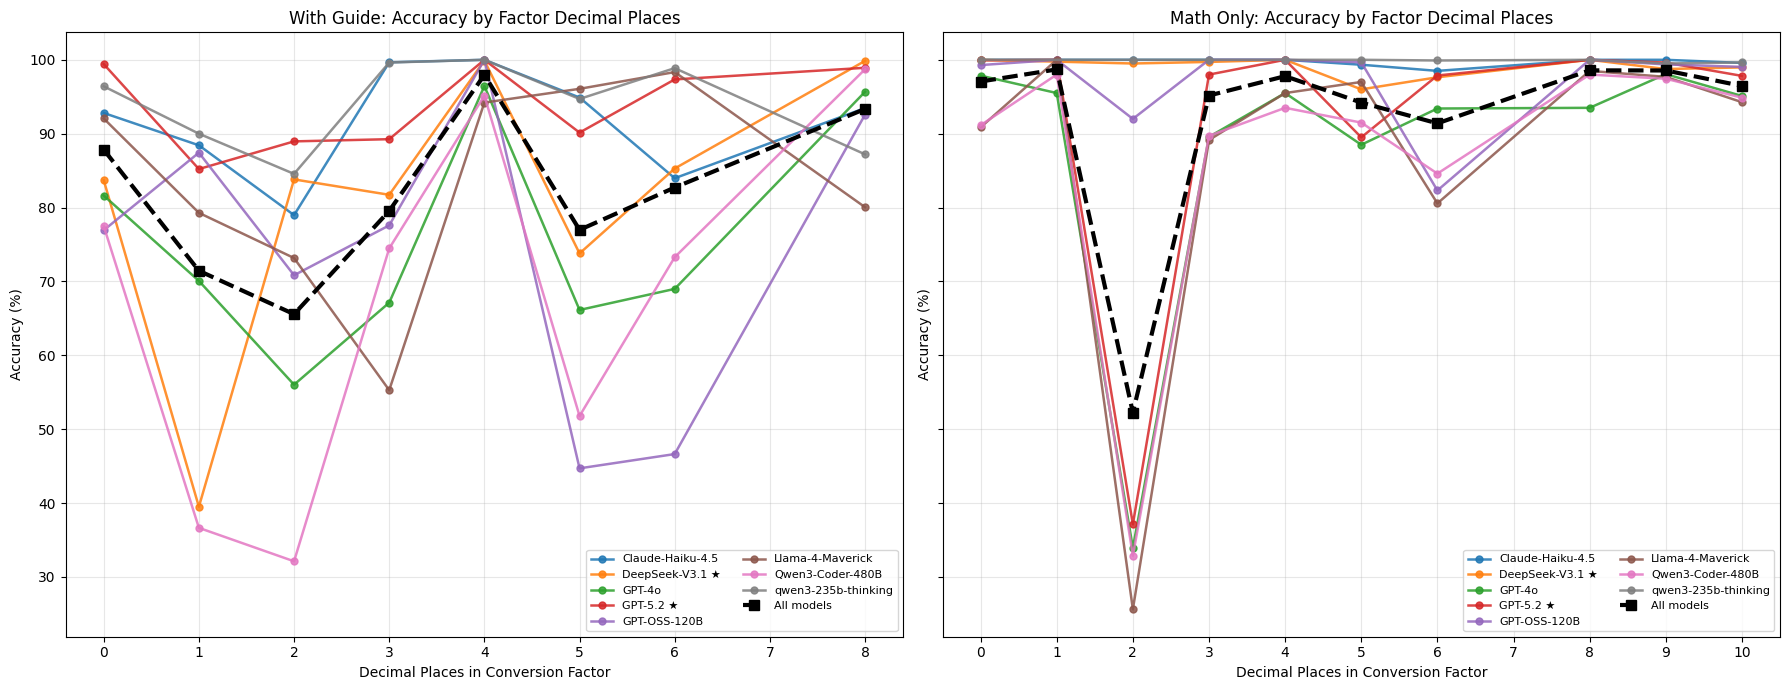


=== Accuracy by factor decimal places (all models combined) ===

With Guide:
                      n  n_correct  accuracy_%
factor_decimals                               
0                578504     508164        87.8
1                  7400       5287        71.4
2                 57624      37783        65.6
3                  7712       6135        79.6
4                 43400      42514        98.0
5                 93000      71588        77.0
6                 95560      79042        82.7
8                 86800      81026        93.3

Math Only:
                      n  n_correct  accuracy_%
factor_decimals                               
0                  9800       9512        97.1
1                  1000        987        98.7
2                  9200       4806        52.2
3                  9800       9326        95.2
4                  1400       1369        97.8
5                  3800       3580        94.2
6                 20400      18645        91.4
8                

In [105]:
# ── Accuracy vs. Number of Decimal Places in the Conversion Factor ──
# Extract the conversion factor's decimal places for with_guide and math_only conditions.
# Question: do models fail more when the factor has many decimal places?

import re

def count_decimal_places(s):
    """Count decimal places as presented in the string.
    For scientific notation, counts mantissa decimals (what the model sees).
    '0.236588' → 6, '1000' → 0, '6.022141e+23' → 6, '1.25e-10' → 2
    """
    s = str(s).strip()
    if 'e' in s.lower():
        mantissa = s.lower().split('e')[0]
        if '.' in mantissa:
            return len(mantissa.split('.')[1].rstrip('0')) or 0
        return 0
    if '.' in s:
        return len(s.split('.')[1].rstrip('0')) or 0
    return 0

def extract_factor_decimals_math_only(prompt):
    """From 'what is 6*0.125' or 'what is (1*9/5)+32', extract the main factor's decimal places."""
    if pd.isna(prompt):
        return None
    # Match the multiplier: number * FACTOR
    m = re.search(r'\*\s*([\d.]+(?:e[+-]?\d+)?)', prompt, re.IGNORECASE)
    if m:
        return count_decimal_places(m.group(1))
    return None

def extract_factor_decimals_with_guide(prompt):
    """Parse the conversion guide to find the target unit's factor, return its decimal places."""
    if pd.isna(prompt):
        return None
    lines = str(prompt).split('\n')
    # Extract target unit from "Convert X [from] to [target]."
    header = lines[0]
    m = re.search(r'(?:Convert|convert)\s+.+?\s+to\s+(.+?)\.?\s*$', header)
    if not m:
        return None
    target_raw = m.group(1).strip().rstrip('.')
    # Normalize: lowercase, replace spaces with underscores
    target_norm = target_raw.lower().replace(' ', '_')

    # Search guide lines for "unit: factor"
    for line in lines:
        line_s = line.strip()
        guide_m = re.match(r'(\S+)\s*:\s*([\d.]+(?:e[+-]?\d+)?)', line_s, re.IGNORECASE)
        if guide_m:
            unit = guide_m.group(1).lower()
            factor = guide_m.group(2)
            # Fuzzy match: target could be plural/singular variant
            if unit in target_norm or target_norm in unit or target_norm.rstrip('s') == unit.rstrip('s'):
                return count_decimal_places(factor)
    return None

# Apply to relevant conditions
df_wg = df_all[df_all['condition'] == 'in_domain_with_guide'].copy()
df_mo = df_all[df_all['condition'] == 'math_only'].copy()

# Exclude temperature, timezone, clothing (non-linear or non-numeric factors)
exclude_domains = ['temperature', 'timezone', 'clothing_size']
df_wg = df_wg[~df_wg['domain'].isin(exclude_domains)]
df_mo = df_mo[~df_mo['domain'].isin(exclude_domains)]

df_wg['factor_decimals'] = df_wg['prompt'].apply(extract_factor_decimals_with_guide)
df_mo['factor_decimals'] = df_mo['prompt'].apply(extract_factor_decimals_math_only)

print(f"With guide: {df_wg['factor_decimals'].notna().sum():,} / {len(df_wg):,} rows parsed")
print(f"Math only:  {df_mo['factor_decimals'].notna().sum():,} / {len(df_mo):,} rows parsed")
print(f"\nWith guide factor_decimals distribution:\n{df_wg['factor_decimals'].value_counts().sort_index()}")
print(f"\nMath only factor_decimals distribution:\n{df_mo['factor_decimals'].value_counts().sort_index()}")

# ── Plot: accuracy by factor decimal places, one line per model ──
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for ax, (label, dfc) in zip(axes, [('With Guide', df_wg), ('Math Only', df_mo)]):
    dfc = dfc[dfc['factor_decimals'].notna()].copy()
    dfc['factor_decimals'] = dfc['factor_decimals'].astype(int)

    stats = (dfc.groupby(['factor_decimals', 'model'])
             .agg(accuracy=('is_correct', 'mean'), n=('is_correct', 'size'))
             .reset_index())
    stats['accuracy_pct'] = stats['accuracy'] * 100

    for model in sorted(stats['model'].unique()):
        sub = stats[stats['model'] == model].sort_values('factor_decimals')
        display = MODEL_DISPLAY.get(model, model)
        ax.plot(sub['factor_decimals'], sub['accuracy_pct'], marker='o', linewidth=1.8,
                markersize=5, label=display, alpha=0.85)

    # Overall trend line (all models)
    overall = (dfc.groupby('factor_decimals')['is_correct'].mean() * 100).reset_index()
    overall.columns = ['factor_decimals', 'accuracy_pct']
    ax.plot(overall['factor_decimals'], overall['accuracy_pct'], color='black', linewidth=3,
            linestyle='--', marker='s', markersize=7, label='All models', zorder=10)

    ax.set_xlabel('Decimal Places in Conversion Factor')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(f'{label}: Accuracy by Factor Decimal Places')
    ax.legend(fontsize=8, ncol=2)
    ax.grid(alpha=0.3)
    ax.set_xticks(range(int(stats['factor_decimals'].max()) + 1))

plt.tight_layout()
plt.show()

# ── Summary table ──
print("\n=== Accuracy by factor decimal places (all models combined) ===")
for label, dfc in [('With Guide', df_wg), ('Math Only', df_mo)]:
    dfc = dfc[dfc['factor_decimals'].notna()].copy()
    dfc['factor_decimals'] = dfc['factor_decimals'].astype(int)
    tbl = dfc.groupby('factor_decimals').agg(
        n=('is_correct', 'size'),
        n_correct=('is_correct', 'sum'),
        accuracy=('is_correct', 'mean')
    )
    tbl['accuracy_%'] = (tbl['accuracy'] * 100).round(1)
    print(f"\n{label}:")
    print(tbl[['n', 'n_correct', 'accuracy_%']].to_string())

In [106]:
# Extract the conversion factor from math_only prompts into a 'factor' column
# e.g. "what is 1*155.5" → 155.5,  "what is (8*9/5)+32" → 9/5 (as float 1.8)

import re

def extract_factor(prompt):
    """Extract the multiplication factor from a math_only prompt."""
    if pd.isna(prompt):
        return None
    p = str(prompt)
    # Pattern: number * FACTOR (possibly with scientific notation)
    m = re.search(r'\*\s*([\d.]+(?:e[+-]?\d+)?)', p, re.IGNORECASE)
    if m:
        try:
            return float(m.group(1))
        except ValueError:
            return None
    return None

df_mo['factor'] = df_mo['prompt'].apply(extract_factor)
print(f"Parsed {df_mo['factor'].notna().sum():,} / {len(df_mo):,} rows")


Parsed 174,400 / 174,400 rows


In [107]:
df_mo.columns

Index(['domain', 'distractor', 'prompt', 'number', 'answer', 'difficulty',
       'raw_response', 'model_answer', 'loss', 'reasoning_tokens',
       'call_seconds', 'model', 'condition', 'frequency', 'frequency_level',
       'is_reasoning', 'display_name', 'is_correct', 'num_decimals',
       'num_input_decimals', 'frequency_difficulty', 'raw_response_length',
       'error_type', 'is_soft_error', 'is_correct_soft', 'is_correct_soft_pct',
       'is_correct_pct', 'has_distractor', 'factor_decimals', 'factor'],
      dtype='object')

In [108]:
df_mo['factor_decimals'].value_counts()

factor_decimals
10    108800
6      20400
0       9800
3       9800
2       9200
9       8800
5       3800
4       1400
8       1400
1       1000
Name: count, dtype: int64

In [109]:
len(df_mo[(df_mo['factor_decimals'] == 1) & (df_mo['is_correct'] == False)])

13

In [110]:
(df_mo[(df_mo['factor_decimals'] == 1) & (df_mo['is_correct'] == False)]).head(30)

,domain,distractor,prompt,number,answer,difficulty,raw_response,model_answer,loss,reasoning_tokens,...,frequency_difficulty,raw_response_length,error_type,is_soft_error,is_correct_soft,is_correct_soft_pct,is_correct_pct,has_distractor,factor_decimals,factor
1452817,currency,NaN,what is 110*155.5,110,17105.0,Easy,<answer>17005</answer>,17005.0,0.584624,0.0,...,hard,22,rounding,True,True,100.0,0.0,False,1,155.5
1452827,currency,NaN,what is 220*155.5,220,34210.0,Easy,<answer>34110.0</answer>,34110.0,0.292312,0.0,...,hard,24,rounding,True,True,100.0,0.0,False,1,155.5
1452833,currency,NaN,what is 280*155.5,280,43540.0,Easy,<answer>43440</answer>,43440.0,0.229674,0.0,...,hard,22,rounding,True,True,100.0,0.0,False,1,155.5
1452839,currency,NaN,what is 450*155.5,450,69975.0,Easy,<answer>69847.5</answer>,69847.5,0.182208,0.0,...,hard,24,rounding,True,True,100.0,0.0,False,1,155.5
1452908,currency,NaN,what is 2948.3*155.5,2948.3,458460.65,Hard,<answer>457976.65</answer>,457976.65,0.105571,0.0,...,hard,26,rounding,True,True,100.0,0.0,False,1,155.5
1452910,currency,NaN,what is 3.8271*155.5,3.8271,595.11405,Hard,<answer>595.7151</answer>,595.7151,0.100997,0.0,...,hard,25,rounding,True,True,100.0,0.0,False,1,155.5
1452920,currency,NaN,what is 4829.5*155.5,4829.5,750987.25,Hard,"<answer>750,067.225</answer>",750067.225,0.122509,0.0,...,hard,28,rounding,True,True,100.0,0.0,False,1,155.5
1452935,currency,NaN,what is 5.2941*155.5,5.2941,823.2325500000001,Hard,<answer>822.1655</answer>,822.1655,0.129617,0.0,...,hard,25,rounding,True,True,100.0,0.0,False,1,155.5
1452958,currency,NaN,what is 3948.2*155.5,3948.2,613945.1,Hard,"<answer>613,263.1</answer>",613263.1,0.111085,0.0,...,hard,26,rounding,True,True,100.0,0.0,False,1,155.5
1601532,currency,NaN,what is 90*155.5,90,13995.0,Easy,<answer>14095.0</answer>,14095.0,0.714541,0.0,...,hard,24,rounding,True,True,100.0,0.0,False,1,155.5


In [ ]:
(df_mo[(df_mo['factor_decimals'] == 2) & (df_mo['is_correct'] == False)])

,domain,distractor,prompt,number,answer,difficulty,raw_response,model_answer,loss,reasoning_tokens,...,frequency_difficulty,raw_response_length,error_type,is_soft_error,is_correct_soft,is_correct_soft_pct,is_correct_pct,has_distractor,factor_decimals,factor
1428806,bits_bytes,NaN,what is 65*1.250000e-07,65,8.125e-06,Easy,<answer>0.00000008125</answer>,8.125e-08,99.000000,0.0,...,hard,30,decimal_shift,False,False,0.0,0.0,False,2,1.250000e-07
1428807,bits_bytes,NaN,what is 70*1.250000e-07,70,8.75e-06,Easy,<answer>0.0000000875</answer>,8.75e-08,99.000000,0.0,...,hard,29,decimal_shift,False,False,0.0,0.0,False,2,1.250000e-07
1428811,bits_bytes,NaN,what is 85*1.250000e-07,85,1.0625e-05,Easy,<answer>0.00000010625</answer>,1.0625e-07,99.000000,0.0,...,hard,30,decimal_shift,False,False,0.0,0.0,False,2,1.250000e-07
1450376,bits_bytes,NaN,what is 9*1.250000e-04,9,0.001125,Easy,<answer>0.0011</answer>,0.0011,2.222222,NaN,...,hard,23,moderate_error,False,False,0.0,0.0,False,2,1.250000e-04
1450377,bits_bytes,NaN,what is 10*1.250000e-04,10,0.00125,Easy,<answer>0.0013</answer>,0.0013,4.000000,NaN,...,easy,23,moderate_error,False,False,0.0,0.0,False,2,1.250000e-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1602483,currency,NaN,what is 98.421*6.94,98.421,683.0417400000001,Hard,81.3037,81.3037,88.096818,NaN,...,hard,7,moderate_error,False,False,0.0,0.0,False,2,6.940000e+00
1602484,currency,NaN,what is 284.93*6.94,284.93,1977.4142,Hard,235.3726,235.3726,88.096950,NaN,...,hard,8,moderate_error,False,False,0.0,0.0,False,2,6.940000e+00
1602485,currency,NaN,what is 49.281*6.94,49.281,342.01014000000004,Hard,40.7097,40.7097,88.096932,NaN,...,hard,7,moderate_error,False,False,0.0,0.0,False,2,6.940000e+00
1602486,currency,NaN,what is 7.2948*6.94,7.2948,50.62591200000001,Hard,6.0267,6.0267,88.095622,NaN,...,hard,6,moderate_error,False,False,0.0,0.0,False,2,6.940000e+00


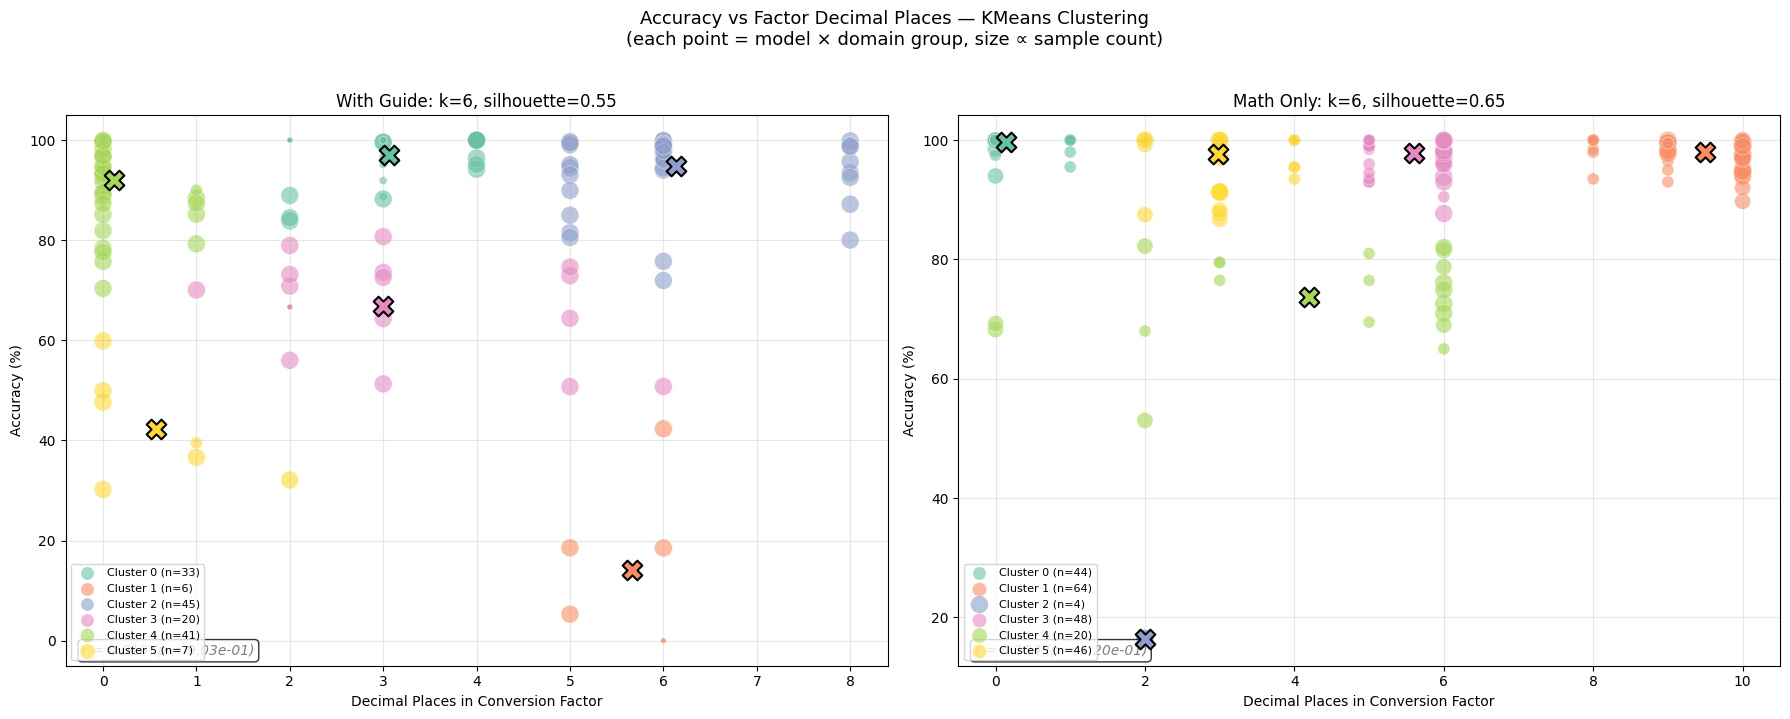


With Guide — cluster profiles:
         n_groups  mean_factor_dec  median_factor_dec  mean_accuracy  median_accuracy
cluster                                                                              
0              33              3.1                3.0           97.0            100.0
1               6              5.7                6.0           14.1             11.9
2              45              6.1                6.0           94.9             97.8
3              20              3.0                2.5           66.9             66.7
4              41              0.1                0.0           92.1             93.5
5               7              0.6                0.0           42.3             39.5

Domains per cluster:
  Cluster 0: ['bits_bytes', 'cooking', 'currency', 'energy']
  Cluster 1: ['bits_bytes', 'energy', 'volume']
  Cluster 2: ['bits_bytes', 'cooking', 'energy', 'moles_to_particles', 'speed', 'volume']
  Cluster 3: ['bits_bytes', 'currency', 'energy', 'volume']

In [112]:
# ── Scatter + clustering: accuracy vs factor decimal places ──
# import scikit-learn as sklearn
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy import stats as sp_stats

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

cluster_results = {}
for ax, (label, dfc) in zip(axes, [('With Guide', df_wg), ('Math Only', df_mo)]):
    dfc = dfc[dfc['factor_decimals'].notna()].copy()
    dfc['factor_decimals'] = dfc['factor_decimals'].astype(int)

    # Each point = one (model, domain, factor_decimals) group
    scatter_df = (dfc.groupby(['model', 'domain', 'factor_decimals'])
                  .agg(accuracy=('is_correct', 'mean'), n=('is_correct', 'size'))
                  .reset_index())
    scatter_df['accuracy_pct'] = scatter_df['accuracy'] * 100

    X = scatter_df[['factor_decimals', 'accuracy_pct']].values
    X_scaled = StandardScaler().fit_transform(X)

    # Pick k via silhouette score
    from sklearn.metrics import silhouette_score
    best_k, best_sil = 2, -1
    for k in range(2, min(7, len(scatter_df))):
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        labs = km.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labs)
        if sil > best_sil:
            best_k, best_sil = k, sil

    km = KMeans(n_clusters=best_k, n_init=10, random_state=42)
    scatter_df['cluster'] = km.fit_predict(X_scaled)

    palette = sns.color_palette('Set2', best_k)
    for cl in range(best_k):
        sub = scatter_df[scatter_df['cluster'] == cl]
        ax.scatter(sub['factor_decimals'], sub['accuracy_pct'],
                   c=[palette[cl]], s=sub['n'].clip(upper=500) * 0.3 + 15,
                   alpha=0.6, edgecolors='white', linewidth=0.4,
                   label=f'Cluster {cl} (n={len(sub)})')

    # Cluster centroids
    centroids = StandardScaler().fit(X).inverse_transform(km.cluster_centers_)
    for ci, (cx, cy) in enumerate(centroids):
        ax.scatter(cx, cy, marker='X', s=200, c=[palette[ci]],
                   edgecolors='black', linewidth=1.5, zorder=10)

    # Pearson correlation
    r, p = sp_stats.pearsonr(scatter_df['factor_decimals'], scatter_df['accuracy_pct'])
    ax.annotate(f'r = {r:.3f} (p = {p:.2e})', xy=(0.02, 0.02), xycoords='axes fraction',
                fontsize=10, fontstyle='italic', color='gray',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

    ax.set_xlabel('Decimal Places in Conversion Factor')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(f'{label}: k={best_k}, silhouette={best_sil:.2f}')
    ax.legend(fontsize=8, loc='lower left')
    ax.grid(alpha=0.3)

    cluster_results[label] = scatter_df

plt.suptitle('Accuracy vs Factor Decimal Places — KMeans Clustering\n(each point = model × domain group, size ∝ sample count)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Cluster summaries ──
for label, sdf in cluster_results.items():
    print(f"\n{'='*60}")
    print(f"{label} — cluster profiles:")
    summary = sdf.groupby('cluster').agg(
        n_groups=('model', 'size'),
        mean_factor_dec=('factor_decimals', 'mean'),
        median_factor_dec=('factor_decimals', 'median'),
        mean_accuracy=('accuracy_pct', 'mean'),
        median_accuracy=('accuracy_pct', 'median'),
        domains=('domain', lambda x: ', '.join(sorted(x.unique()))),
    ).round(1)
    print(summary[['n_groups', 'mean_factor_dec', 'median_factor_dec', 'mean_accuracy', 'median_accuracy']].to_string())
    print(f"\nDomains per cluster:")
    for cl in sorted(sdf['cluster'].unique()):
        doms = sorted(sdf[sdf['cluster'] == cl]['domain'].unique())
        print(f"  Cluster {cl}: {doms}")